In [1]:
import sys
import os
sys.path.append(os.path.abspath('/bigdata/saleslab/psadh003/tng50/dwarf_formation'))
import pandas as pd 
import matplotlib.pyplot as plt

import IPython
import numpy as np 
from dwarf_plotting import plot_lg_virgo, plot_lg_vd, plot_lg_virgo_some
# from Pradyumna_plot import plot_tng_subhalos #This is to plot the subhalos from TNG
import matplotlib
import illustris_python as il
from errani_plus_tng_subhalo import Subhalo
from populating_stars import *
from subhalo_profiles import NFWProfile
import ast
from colossus.cosmology import cosmology
from colossus.halo import concentration
from plot_sachi import plot_sachi
from scipy.optimize import fsolve
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.collections as mc
from matplotlib.legend_handler import HandlerTuple
from testing_errani import get_rmxbyrmx0, get_vmxbyvmx0, get_mxbymx0, get_LbyL0, l10rbyrmx0_1by4_spl,l10rbyrmx0_1by2_spl, l10rbyrmx0_1by8_spl, l10rbyrmx0_1by16_spl, l10vbyvmx0_1by2_spl, l10vbyvmx0_1by4_spl, l10vbyvmx0_1by8_spl, l10vbyvmx0_1by16_spl, l10rbyrmx0_1by66_spl, l10rbyrmx0_1by250_spl, l10rbyrmx0_1by1000_spl, l10vbyvmx0_1by66_spl, l10vbyvmx0_1by250_spl, l10vbyvmx0_1by1000_spl
import matplotlib.ticker as ticker
import re

cosmology.setCosmology('planck18')


ages_df = pd.read_csv('/bigdata/saleslab/psadh003/tng50-dark-analysis/ages_tng.csv', comment = '#')

all_snaps = np.array(ages_df['snapshot'])
all_redshifts = np.array(ages_df['redshift'])
all_ages = np.array(ages_df['age(Gyr)'])

/bigdata/saleslab/psadh003/tng50/dwarf_formation/dwarf_plotting.py:55: RuntimeWarning: invalid value encountered in sqrt
  rh_proj *= np.sqrt(1.-ell)


A new version of galpy (1.11.2) is available, please upgrade using pip/conda/... to get the latest features and bug fixes!


In [2]:
import os
os.environ['PATH']

'/opt/linux/rocky/8.x/x86_64/pkgs/jupyterlab/4.0.1/bin:/opt/linux/rocky/8.x/x86_64/pkgs/miniconda3/py39_4.12.0/bin:/opt/linux/rocky/8.x/x86_64/pkgs/miniconda3/py39_4.12.0/bin:/opt/linux/rhel/8.x/x86_64/pkgs/miniconda3/py39_4.12.0/condabin:/usr/share/Modules/bin:/usr/bin:/bin:/usr/local/games:/usr/games:/usr/local/bin:/usr/lpp/mmfs/bin'

In [3]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size' : 14}

plt.figure()
plt.close()
matplotlib.rc('font', **font)
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelweight'] = 'bold'


label_font = 20
figpath = '/bigdata/saleslab/psadh003/tng50/paper1_plots_nohof/'

In [4]:
def convert_to_float(value):
    try:
        if isinstance(value, float) or isinstance(value, int):
            return value

        if value == '[inf, inf, inf]' or value == '[inf inf inf]':
            return np.array([np.inf, np.inf, np.inf])

        if value == '[inf]':
            return np.inf
        
        if value == 'inf':
            return np.inf
        

        if value == '[-inf]':
            return -np.inf

        

        blah = ast.literal_eval(value)
        if isinstance(blah, list):
            if len(blah) == 1:
                blah2 = float(blah[0])   
            elif len(blah) == 3:
                blah2 = np.array([float(blah[0]), float(blah[1]), float(blah[2])])
        else:
            blah2 = float(blah)        
        return blah2
    except Exception as e:
        try:
            value_fixed = re.sub(r'(?<=\d)\s+(?=-?\d)', ', ', value)  # Handle spaces between numbers
            value_fixed = re.sub(r'(?<=\d)\s+(?=\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=-\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=\d)', ', ', value_fixed)
            # Now use ast.literal_eval
            # print(value_fixed)
            result = ast.literal_eval(value_fixed)
            return result
        except Exception as e:
            print(value)
            return value
        
def get_med_values(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.median(np.reshape(arr, (cuts, -1)), axis = 0)

def get_quantiles(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.quantile(np.reshape(arr, (cuts, -1)), axis = 0, q = [0.05, 0.95])

In [5]:
basePath = '/rhome/psadh003/bigdata/L35n2160TNG_fixed/output'
outpath  = '/rhome/psadh003/bigdata/tng50/output_files/'
plotpath = '/bigdata/saleslab/psadh003/tng50/output_plots/'
misc_path = '/bigdata/saleslab/psadh003/misc_files/'
ferrarese_data_path = '/bigdata/saleslab/psadh003/misc_files/Ferrarese_virgo_smf.csv'
venhola_data_path = '/bigdata/saleslab/psadh003/misc_files/Venhola_fornax_smf.csv'

In [6]:
'''
This part is to plot the NGVS data of virgo core set of satellites
'''
fdata = pd.read_csv(ferrarese_data_path, delimiter = ',')
fmstar = fdata['mstar']
fngal = fdata['ngal']
fngal_cum = np.cumsum(fngal)

'''
This part is to plot the Fornax mass function (everything inside virial radius)
'''
vdata = pd.read_csv(venhola_data_path, delimiter = ',')
vmstar = vdata['mstar']
vngal = vdata['ngal']
vngal_cum = np.cumsum(vngal)


In [7]:
h = 0.6774 # Hubble constant / 100
G = 4.3e-6 #kpc, km/s, Msun

def nfw_mass(r, lrhos, lrs):
    '''
    This gives the NFW mass profile at a given radius r, we do not care much about the units here, since we normalize the density profile later
    '''
    rhos = 10**lrhos
    rs = 10**lrs
    mass =  4 * np.pi * rhos * rs ** 3 * (np.log(1 + (r/rs))  -  r / (r + rs))
    return mass


def nfw_dens(r, rhos, rs):
    '''
    This gives the NFW density profile at a given radius r, we do not care much about the units here
    since we normalize the density profile later
    '''
    dens = rhos / ((r/rs) * (1 + (r / rs)) ** 2)
    return dens



# Following calculations are for the best-fit NFW profiles


# ================== For the FoF-0 ==================

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 0)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_0 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_0 = this_fof['Group_R_Crit200'] / h
v200_0 = np.sqrt(G * m200_0 / r200_0)
central_sfid_99_0 = central_sfid_99


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    # result = np.array([np.log10(nfw_mass(rh, lrhos, lrs)) - np.log10(float(mdm_rh)), np.log10(nfw_mass(r_vmax, lrhos, lrs)) - np.log10(float(mdm_vmax)), 
    #                    np.log10(nfw_mass(2 * rh, lrhos, lrs)) - np.log10(float(mdm_2rh))]).ravel()
    # print(f"Params: {params}, Result: {result}")
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_0 = 10**lrhos
rs_0 = 10**lrs

# ======================= For the FoF-1 =======================

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 1)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_1 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_1 = this_fof['Group_R_Crit200'] / h
v200_1 = np.sqrt(G * m200_1 / r200_1)
central_sfid_99_1 = central_sfid_99


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    # result = np.array([np.log10(nfw_mass(rh, lrhos, lrs)) - np.log10(float(mdm_rh)), np.log10(nfw_mass(r_vmax, lrhos, lrs)) - np.log10(float(mdm_vmax)), 
    #                    np.log10(nfw_mass(2 * rh, lrhos, lrs)) - np.log10(float(mdm_2rh))]).ravel()
    # print(f"Params: {params}, Result: {result}")
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_1 = 10**lrhos
rs_1 = 10**lrs


# ============== For the FoF-2 =================


this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 2)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_2 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_2 = this_fof['Group_R_Crit200'] / h
v200_2 = np.sqrt(G * m200_2 / r200_2)
central_sfid_99_2 = central_sfid_99


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_2 = 10**lrhos
rs_2 = 10**lrs


# We now have the best-fit NFW parameters for the FoF-0, FoF-1 and FoF-2 halos, we can now use these to get the density profiles for the subhalos

In [8]:
from scipy.optimize import curve_fit

def einasto_density(lr, lrhos, lrs, lalpha):
    '''
    This gives the Einasto density profile at a given radius r, we do not care much about the units here
    since we normalize the density profile later
    '''
    r = 10**lr
    rhos = 10**lrhos
    rs = lrs
    alpha = lalpha
    dens = rhos * np.exp((-2/alpha) * ((r/rs) ** alpha - 1))
    return np.log10(dens)


def fit_einasto(r, density):
    """
    Fit the Einasto profile to the given density data.

    Parameters
    ----------
    r : array-like
        Radial distances.
    density : array-like
        Observed density values.

    Returns
    -------
    params : tuple
        Best-fit parameters (rho_s, r_s, alpha).
    cov : 2D array
        Covariance matrix of the fit.
    """
    # Initial guesses for parameters (can be adjusted based on data)
    rho_s_guess = density.max()
    r_s_guess = r[np.argmax(density)]
    alpha_guess = 1.5
    
    print(rho_s_guess, r_s_guess, alpha_guess)
    # p0 = [np.log10(rho_s_guess), np.log10(r_s_guess), alpha_guess]
    p0 = [np.log10(rho_s_guess), 0.1, alpha_guess]
    
    # Perform the curve fitting
    try:
        params, cov = curve_fit(einasto_density, np.log10(r), np.log10(density), p0=p0, bounds=((-1, 0.1, 0.1), (10, 10**-0.23, 2)))
        return params, cov
    except RuntimeError as e:
        print("Fit did not converge:", e)
        return None, None


In [9]:
# This would be the information for Type-1 subhalos
filepath = '/bigdata/saleslab/psadh003/tng50dark/tng_files/'

df0 = pd.read_csv(filepath +  'hydrofofno_' + str(0) + '.csv', delimiter = ',', low_memory=False)
df1 = pd.read_csv(filepath +  'hydrofofno_' + str(1) + '.csv', delimiter = ',', low_memory=False)
df2 = pd.read_csv(filepath +  'hydrofofno_' + str(2) + '.csv', delimiter = ',', low_memory=False)
df = pd.concat([df0, df1, df2], ignore_index = True)
t1_vmax_if_ar = df['vmax_if_ar'].values
t1_vpeak_ar = df['vpeak'].values
t1_snap_if_ar = np.array(df['snap_if_ar'].values, dtype = int)
t1_sfid_if_ar = np.array(df['sfid_if_ar'].values, dtype = int)
t1_fof = df['fof'].values


In [10]:
# Let us combine all the three set of files which have the data for the distance of Type-2 subhalos
df0 = pd.read_csv(filepath + 'hydrofofno_' + str(0) + '_t2.csv', comment = '#')
# df0['fof'] = 0
df1 = pd.read_csv(filepath + 'hydrofofno_' + str(1) + '_t2.csv', comment = '#')
df2 = pd.read_csv(filepath + 'hydrofofno_' + str(2) + '_t2.csv', comment = '#')
df = pd.concat([df0, df1, df2], ignore_index = True)
t2_snap_if_ar = np.array(df['snap_if_ar'], dtype=int) # This is the infall snap of the subhalo
t2_sfid_if_ar = np.array(df['sfid_if_ar'], dtype=int) # This is the infall sfid of the subhalo
t2_snap_merger_ar = np.array(df['snap_merger_ar'], dtype=int) # This is the merger snap of the subhalo
t2_sfid_merger_ar = np.array(df['sfid_merger_ar'], dtype = int) # This is the merger sfid of the subhalo
t2_posx_ar = np.array(df['posx_ar']) # This is the x position of the subhalo
t2_posy_ar = np.array(df['posy_ar']) # This is the y position of the subhalo
t2_posz_ar = np.array(df['posz_ar']) # This is the z position of the subhalo
t2_dist_ar = np.sqrt(t2_posx_ar ** 2 + t2_posy_ar ** 2 + t2_posz_ar ** 2) # This is the distance of the subhalo from the center of the FoF
t2_vmax_if_ar = np.array(df['vmax_if_ar']) # This is the vmax of the subhalo
t2_vpeak_ar = np.array(df['vpeak']) # This is the vpeak of the subhalo
t2_fof = np.array(df['fof']) # This is the fof of the subhalo
t2_sfid_into_ar = np.array(df['sfid_into_ar'], dtype = int) # This is the sfid of the subhalo into which the subhalo has fallen into

In [14]:
# suffix = '_newpl' # This is the attempt where we have used the new power law
# suffix = '_Vpeak_newall' # This is the attempt where we have used the new power law
# suffix = '_vpeak_bestfits' # This is the attempt where we have used the new power law
# suffix = '_interpolation' # This is the attempt where we have used the new power law
suffix = '_interpolation_different_co' # This is the attempt where we have used the new power law
filepath = '/bigdata/saleslab/psadh003/tng50dark/tng_files/'

df0 = pd.read_csv(filepath + 'fof0_surviving_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df1 = pd.read_csv(filepath + 'fof1_surviving_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df2 = pd.read_csv(filepath + 'fof2_surviving_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)

a4_t1_df = pd.concat([df0, df1, df2], ignore_index = True)  # This is the dataframe for the surviving subhalos

a4_t1_df = a4_t1_df.applymap(convert_to_float)
a4_t1_dist_f_ar = a4_t1_df['dist_f_ar'].values
a4_t1_hof_flag = a4_t1_df['hof_flag'].values
a4_t1_fof = a4_t1_df['fof'].values

a4_t1_rrel = np.zeros(len(a4_t1_fof))
a4_t1_rrel[a4_t1_fof == 0] = a4_t1_dist_f_ar[a4_t1_fof == 0] / r200_0
a4_t1_rrel[a4_t1_fof == 1] = a4_t1_dist_f_ar[a4_t1_fof == 1] / r200_1
a4_t1_rrel[a4_t1_fof == 2] = a4_t1_dist_f_ar[a4_t1_fof == 2] / r200_2



#=============================
# This is where we apply the conditions
#=============================

a4_t1_df = a4_t1_df[(a4_t1_dist_f_ar > 50) & a4_t1_hof_flag & (a4_t1_rrel < 1)]
a4_t1_dist_f_ar = a4_t1_df['dist_f_ar'].values

#==============================
a4_t1_mstar_max_ar = a4_t1_df['mstar_max_ar'].values
a4_t1_rh_max_ar = a4_t1_df['rh_max_ar'].values
a4_t1_rh_f_ar = a4_t1_df['rh_f_ar'].values
a4_t1_rh_f_pl_ar = a4_t1_df['rh_f_pl_ar'].values
a4_t1_rh_f_co_ar = a4_t1_df['rh_f_co_ar'].values
a4_t1_rh_max_pl_ar = a4_t1_df['rh_max_pl_ar'].values
a4_t1_rh_max_co_ar = a4_t1_df['rh_max_co_ar'].values
a4_t1_mstar_f_ar_tng = a4_t1_df['mstar_f_ar_tng'].values
a4_t1_mmx_f_ar_tng = a4_t1_df['mmx_f_ar_tng'].values
a4_t1_rmx_f_ar_tng = a4_t1_df['rmx_f_ar_tng'].values
a4_t1_rh_f_ar_tng = a4_t1_df['rh_f_ar_tng'].values
a4_t1_rmx_if_ar = a4_t1_df['rmx_if_ar'].values
a4_t1_mstar_max_pl_ar = a4_t1_df['mstar_max_pl_ar'].values
a4_t1_mstar_max_co_ar = a4_t1_df['mstar_max_co_ar'].values
a4_t1_mstar_f_ar = a4_t1_df['mstar_f_ar'].values
a4_t1_mstar_f_pl_ar = a4_t1_df['mstar_f_pl_ar'].values
a4_t1_mstar_f_co_ar = a4_t1_df['mstar_f_co_ar'].values
a4_t1_mstar_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_mstar_co_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_co_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_max_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_max_co_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_mstar_if_ar = a4_t1_df['mstar_if_ar'].values
a4_t1_snap_if_ar = a4_t1_df['snap_if_ar'].values
a4_t1_fof = a4_t1_df['fof'].values
a4_t1_sfid_if_ar = a4_t1_df['sfid_if_ar'].values
a4_t1_vmx_if_ar  = a4_t1_df['vmx_if_ar'].values
a4_t1_rperi_ar = a4_t1_df['rperi_ar'].values
a4_t1_rapo_ar = a4_t1_df['rapo_ar'].values
a4_t1_mmx_if_ar = a4_t1_df['mmx_if_ar'].values
a4_t1_mmx_f_ar = a4_t1_df['mmx_f_ar'].values
a4_t1_rmx_f_ar = a4_t1_df['rmx_f_ar'].values
a4_t1_vmax_if_ar = a4_t1_df['vmax_if_ar'].values
a4_t1_vpeak_ar = a4_t1_df['vpeak_ar'].values
a4_t1_torb = a4_t1_df['torb_ar'].values
a4_t1_hof_flag = a4_t1_df['hof_flag'].values


massive_ixs = np.where(a4_t1_mstar_max_ar > 1e11)[0]
res_ixs = np.where((a4_t1_mstar_max_ar > 5e6) & (a4_t1_mstar_max_ar < 1e11))[0]
unres_ixs = np.where(a4_t1_mstar_max_ar < 5e6)[0]

a4_t1_mstar_pl_all[res_ixs] = a4_t1_mstar_f_ar[res_ixs]
a4_t1_mstar_pl_all[unres_ixs] = a4_t1_mstar_f_pl_ar[unres_ixs]
a4_t1_mstar_pl_all[massive_ixs] = a4_t1_mstar_f_ar_tng[massive_ixs]

a4_t1_mstar_co_all[res_ixs] = a4_t1_mstar_f_ar[res_ixs]
a4_t1_mstar_co_all[unres_ixs] = a4_t1_mstar_f_co_ar[unres_ixs]
a4_t1_mstar_co_all[massive_ixs] = a4_t1_mstar_f_ar_tng[massive_ixs]

a4_t1_mstar_max_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_mstar_max_co_all = np.zeros(len(a4_t1_dist_f_ar))

a4_t1_mstar_max_pl_all[res_ixs] = a4_t1_mstar_max_ar[res_ixs]
a4_t1_mstar_max_pl_all[unres_ixs] = a4_t1_mstar_max_pl_ar[unres_ixs]
a4_t1_mstar_max_pl_all[massive_ixs] = a4_t1_mstar_max_ar[massive_ixs]

a4_t1_mstar_max_co_all[res_ixs] = a4_t1_mstar_max_ar[res_ixs]
a4_t1_mstar_max_co_all[unres_ixs] = a4_t1_mstar_max_co_ar[unres_ixs]
a4_t1_mstar_max_co_all[massive_ixs] = a4_t1_mstar_max_ar[massive_ixs]

a4_t1_rh_pl_all[res_ixs] = a4_t1_rh_f_ar[res_ixs]
a4_t1_rh_pl_all[unres_ixs] = a4_t1_rh_f_pl_ar[unres_ixs]
a4_t1_rh_pl_all[massive_ixs] = a4_t1_rh_f_ar_tng[massive_ixs]

a4_t1_rh_co_all[res_ixs] = a4_t1_rh_f_ar[res_ixs]
a4_t1_rh_co_all[unres_ixs] = a4_t1_rh_f_co_ar[unres_ixs]
a4_t1_rh_co_all[massive_ixs] = a4_t1_rh_f_ar_tng[massive_ixs]


a4_t1_rh_max_pl_all[res_ixs] = a4_t1_rh_max_ar[res_ixs]
a4_t1_rh_max_pl_all[unres_ixs] = a4_t1_rh_max_pl_ar[unres_ixs]
a4_t1_rh_max_pl_all[massive_ixs] = a4_t1_rh_max_ar[massive_ixs]

a4_t1_rh_max_co_all[res_ixs] = a4_t1_rh_max_ar[res_ixs]
a4_t1_rh_max_co_all[unres_ixs] = a4_t1_rh_max_co_ar[unres_ixs]
a4_t1_rh_max_co_all[massive_ixs] = a4_t1_rh_max_ar[massive_ixs]

a4_t1_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_pl_all/(np.pi * (a4_t1_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t1_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_co_all/(np.pi * (a4_t1_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t1_sigma_max_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_max_pl_all/(np.pi * (a4_t1_rh_max_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t1_sigma_max_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_max_co_all/(np.pi * (a4_t1_rh_max_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2

a4_t1_pos_f_ar = np.stack(np.array(a4_t1_df['pos_f_ar'].values))
#Calculating the projected distances
a4_t1_xy_dist_f_ar = np.sqrt(a4_t1_pos_f_ar[:, 0] ** 2 + a4_t1_pos_f_ar[:, 1] ** 2)
a4_t1_xz_dist_f_ar = np.sqrt(a4_t1_pos_f_ar[:, 0] ** 2 + a4_t1_pos_f_ar[:, 2] ** 2)
a4_t1_yz_dist_f_ar = np.sqrt(a4_t1_pos_f_ar[:, 1] ** 2 + a4_t1_pos_f_ar[:, 2] ** 2)

/tmp/ipykernel_2750729/279116790.py:113: RuntimeWarning: invalid value encountered in log10
  a4_t1_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_pl_all/(np.pi * (a4_t1_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2

/tmp/ipykernel_2750729/279116790.py:114: RuntimeWarning: invalid value encountered in log10
  a4_t1_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_co_all/(np.pi * (a4_t1_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2



In [15]:
# This is the cell for Type-2s input
filepath = '/bigdata/saleslab/psadh003/tng50dark/tng_files/'
# suffix = '_newpl' # This is the attempt where we have used the new power law
# suffix = '_Vpeak_newall' # This is the attempt where we have used the new power law
# suffix = '_vpeak_bestfits' # This is the attempt where we have used the new power law
# suffix = '_interpolation' # This is the attempt where we have used the new power law
suffix = '_interpolation_different_co' # This is the attempt where we have used the new power law
df0 = pd.read_csv(filepath + 'fof0_merged_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df1 = pd.read_csv(filepath + 'fof1_merged_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df2 = pd.read_csv(filepath + 'fof2_merged_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)

a4_t2_df = pd.concat([df0, df1, df2], ignore_index = True)  # This is the dataframe for the merged subhalos


a4_t2_df = a4_t2_df.applymap(convert_to_float)

# ==============================
# This is where we apply the conditions
# ==============================
a4_t2_posx_ar = a4_t2_df['posx'].values
a4_t2_posy_ar = a4_t2_df['posy'].values
a4_t2_posz_ar = a4_t2_df['posz'].values
a4_t2_hof_flag = a4_t2_df['hof_flag'].values
a4_t2_desc_flag = a4_t2_df['desc_flag'].values
a4_t2_desc_flag = a4_t2_desc_flag.astype(bool)

a4_t2_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posy_ar ** 2 + a4_t2_posz_ar ** 2)

print(f'Fraction that pass desc_flag are', np.sum(a4_t2_desc_flag) / len(a4_t2_desc_flag))
a4_t2_fof = a4_t2_df['fof'].values
a4_t2_rrel = np.zeros(len(a4_t2_fof))
a4_t2_rrel[a4_t2_fof == 0] = a4_t2_dist_f_ar[a4_t2_fof == 0] / r200_0
a4_t2_rrel[a4_t2_fof == 1] = a4_t2_dist_f_ar[a4_t2_fof == 1] / r200_1
a4_t2_rrel[a4_t2_fof == 2] = a4_t2_dist_f_ar[a4_t2_fof == 2] / r200_2
# print(a4_t2_hof_flag)
# print(a4_t2_desc_flag)
a4_t2_df = a4_t2_df[(a4_t2_dist_f_ar > 50) & a4_t2_desc_flag  & a4_t2_hof_flag & (a4_t2_rrel < 1)]
# ==============================

a4_t2_posx_ar = a4_t2_df['posx'].values
a4_t2_posy_ar = a4_t2_df['posy'].values
a4_t2_posz_ar = a4_t2_df['posz'].values
a4_t2_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posy_ar ** 2 + a4_t2_posz_ar ** 2)


a4_t2_mstar_max_ar = a4_t2_df['mstar_max_ar'].values
a4_t2_mstar_max_pl_ar = a4_t2_df['mstar_max_pl_ar'].values
a4_t2_mstar_max_co_ar = a4_t2_df['mstar_max_co_ar'].values
a4_t2_rh_max_ar = a4_t2_df['rh_max_ar'].values
a4_t2_mstar_f_ar = a4_t2_df['mstar_f_ar'].values
a4_t2_mstar_f_pl_ar = a4_t2_df['mstar_f_pl_ar'].values
a4_t2_mstar_f_co_ar = a4_t2_df['mstar_f_co_ar'].values
a4_t2_rh_max_pl_ar = a4_t2_df['rh_max_pl_ar'].values
a4_t2_rh_max_co_ar = a4_t2_df['rh_max_co_ar'].values
a4_t2_rh_f_ar = a4_t2_df['rh_f_ar'].values
a4_t2_rh_f_pl_ar = a4_t2_df['rh_f_pl_ar'].values
a4_t2_rh_f_co_ar = a4_t2_df['rh_f_co_ar'].values
a4_t2_vmax_if_ar = a4_t2_df['vmax_if_ar'].values
a4_t2_fof = a4_t2_df['fof'].values
a4_t2_vmx_if_ar  = a4_t2_df['vmx_if_ar'].values
a4_t2_rmx_if_ar = a4_t2_df['rmx_if_ar'].values
a4_t2_rperi_ar = a4_t2_df['rperi_ar'].values
a4_t2_rapo_ar = a4_t2_df['rapo_ar'].values
a4_t2_torb = a4_t2_df['torb_ar'].values

a4_t2_merger_snap = a4_t2_df['merger_snap'].values
a4_t2_merger_sfid = a4_t2_df['merger_sfid'].values
a4_t2_desc_flag = a4_t2_df['desc_flag'].values
a4_t2_desc_flag = a4_t2_desc_flag.astype(bool)


a4_t2_mmx_if_ar = a4_t2_df['mmx_if_ar'].values
a4_t2_mmx_f_ar = a4_t2_df['mmx_f_ar'].values
a4_t2_mstar_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_mstar_co_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_max_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_max_co_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_mstar_max_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_mstar_max_co_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_co_all = np.zeros(len(a4_t2_mstar_max_ar))

a4_t2_mstar_if_ar = a4_t2_df['mstar_if_ar'].values

a4_t2_snap_if_ar = a4_t2_df['snap_if_ar'].values
a4_t2_sfid_if_ar = a4_t2_df['sfid_if_ar'].values
a4_t2_vpeak_ar = a4_t2_df['vpeak_ar'].values
 # This is the distance of the subhalo from the center of the FoF
a4_t2_xy_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posy_ar ** 2)
a4_t2_xz_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posz_ar ** 2)
a4_t2_yz_dist_f_ar = np.sqrt(a4_t2_posy_ar ** 2 + a4_t2_posz_ar ** 2)

# massive_ixs = np.where(a4_t2_mstar_max_ar > 1e11)[0]
res_ixs = np.where((a4_t2_mstar_max_ar > 5e6))[0]
unres_ixs = np.where(a4_t2_mstar_max_ar < 5e6)[0]

a4_t2_mstar_pl_all[res_ixs] = a4_t2_mstar_f_ar[res_ixs]
a4_t2_mstar_pl_all[unres_ixs] = a4_t2_mstar_f_pl_ar[unres_ixs]
# a4_t2_mstar_pl_all[massive_ixs] = a4_t2_mstar_f_ar_tng[massive_ixs]

a4_t2_mstar_co_all[res_ixs] = a4_t2_mstar_f_ar[res_ixs]
a4_t2_mstar_co_all[unres_ixs] = a4_t2_mstar_f_co_ar[unres_ixs]

a4_t2_mstar_max_pl_all[res_ixs] = a4_t2_mstar_max_ar[res_ixs]
a4_t2_mstar_max_pl_all[unres_ixs] = a4_t2_mstar_max_pl_ar[unres_ixs]

a4_t2_mstar_max_co_all[res_ixs] = a4_t2_mstar_max_ar[res_ixs]
a4_t2_mstar_max_co_all[unres_ixs] = a4_t2_mstar_max_co_ar[unres_ixs]

a4_t2_rh_max_pl_all[res_ixs] = a4_t2_rh_max_ar[res_ixs]
a4_t2_rh_max_pl_all[unres_ixs] = a4_t2_rh_max_pl_ar[unres_ixs]

a4_t2_rh_max_co_all[res_ixs] = a4_t2_rh_max_ar[res_ixs]
a4_t2_rh_max_co_all[unres_ixs] = a4_t2_rh_max_co_ar[unres_ixs]

a4_t2_rh_pl_all[res_ixs] = a4_t2_rh_f_ar[res_ixs]
a4_t2_rh_pl_all[unres_ixs] = a4_t2_rh_f_pl_ar[unres_ixs]

a4_t2_rh_co_all[res_ixs] = a4_t2_rh_f_ar[res_ixs]
a4_t2_rh_co_all[unres_ixs] = a4_t2_rh_f_co_ar[unres_ixs]

a4_t2_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_pl_all/(np.pi * (a4_t2_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t2_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_co_all/(np.pi * (a4_t2_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t2_sigma_max_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_max_pl_all/(np.pi * (a4_t2_rh_max_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t2_sigma_max_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_max_co_all/(np.pi * (a4_t2_rh_max_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2


Fraction that pass desc_flag are 0.9537677962703028
/tmp/ipykernel_2750729/1971826767.py:122: RuntimeWarning: invalid value encountered in log10
  a4_t2_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_pl_all/(np.pi * (a4_t2_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2

/tmp/ipykernel_2750729/1971826767.py:123: RuntimeWarning: invalid value encountered in log10
  a4_t2_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_co_all/(np.pi * (a4_t2_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2



/bigdata/saleslab/psadh003/tng50/dwarf_formation/populating_stars.py:27: RuntimeWarning: divide by zero encountered in log10
  return np.log10(mstar)



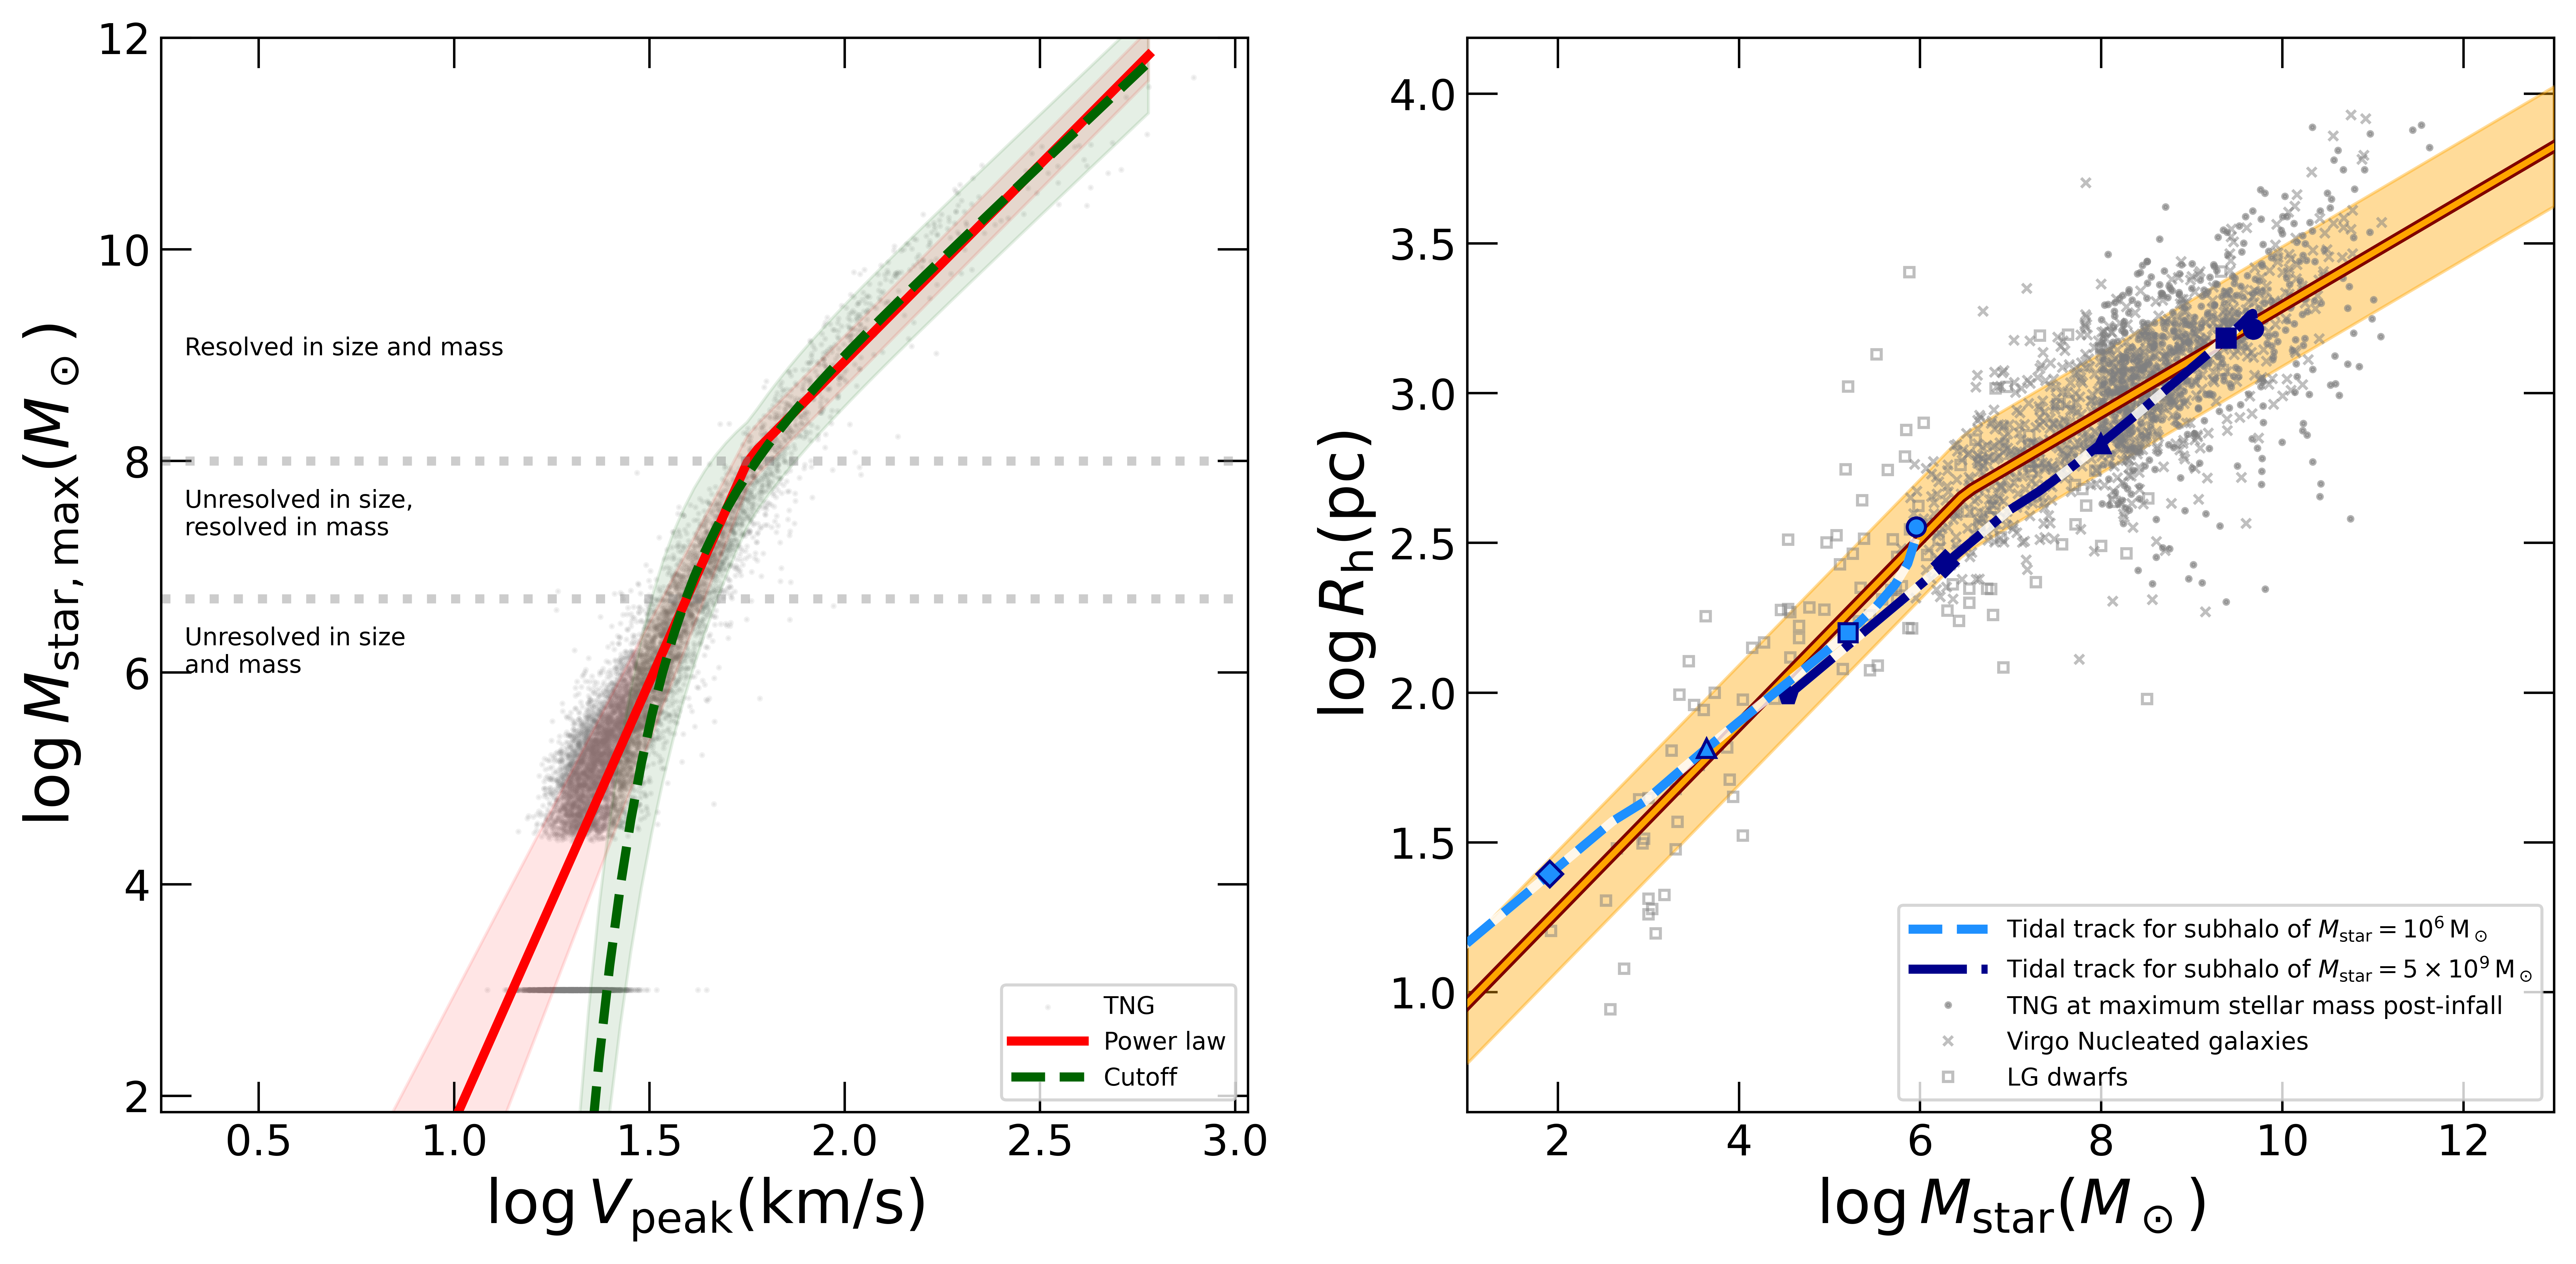

In [21]:
def get_mstar_pl(lvmaxar, m1 = 3.72, m2 = 8.3, b = 1.5):
    '''
    This is the power law model from Santos-Santos 2022
    Input is the log of Vmax
    '''
    vchange  = 57
    if isinstance(lvmaxar, (float, np.float64, np.float32)):
        if lvmaxar >= np.log10(vchange):
            lmstar = m1 * lvmaxar + b
        elif lvmaxar < np.log10(vchange):
            lmstar = m2 * lvmaxar + (m1 - m2)*np.log10(vchange) + b
        lmstarar = lmstar 
    else:
        lmstarar = np.zeros(0)
        for lvmax in lvmaxar:
            if lvmax >= np.log10(vchange):
                lmstar = m1 * lvmax + b
            elif lvmax < np.log10(vchange):
                lmstar = m2 * lvmax + (m1 - m2)*np.log10(vchange) + b
            lmstarar = np.append(lmstarar, lmstar)
    return lmstarar




fig, (ax, ax2) = plt.subplots(1, 2, figsize = (12, 6), dpi = 700)
a4_t1_mstar_max_ar1 = np.copy(a4_t1_mstar_max_ar)
a4_t1_mstar_max_ar1[a4_t1_mstar_max_ar1 == 0] = 1e3 # Setting the mass of the subhalos which are not resolved in mass to 1e3
lvmax_pl = np.linspace(0.1, np.log10(600), 100)
ax.scatter(np.log10(a4_t1_vpeak_ar), np.log10(a4_t1_mstar_max_ar1), color = 'gray', marker = 'o', s = 1, alpha = 0.1, label = 'TNG')
ax.plot(lvmax_pl, get_mstar_pl(lvmax_pl), color = 'red', label = 'Power law')
ax.fill_between(lvmax_pl, get_mstar_pl(lvmax_pl) - get_scatter(lvmax_pl), get_mstar_pl(lvmax_pl) + get_scatter(lvmax_pl), color = 'red', alpha = 0.1)
ax.plot(lvmax_pl, get_mstar_co(lvmax_pl), color = 'darkgreen', label = 'Cutoff', ls = '--')
ax.fill_between(lvmax_pl, get_mstar_co(lvmax_pl) - 2 * get_scatter(lvmax_pl), get_mstar_co(lvmax_pl) + 2 * get_scatter(lvmax_pl), color = 'darkgreen', alpha = 0.1)
ax.set_ylabel(r'$\log M_{\rm{star, max}}(M_\odot)$', fontsize = label_font)
ax.set_xlabel(r'$\log V_{\rm{peak}}(\rm{km/s})$', fontsize = label_font)
ax.axhline(np.log10(5e6), ls = ':', color = 'gray', alpha = 0.4)
ax.text(0.31, 6, 'Unresolved in size\nand mass', fontsize = 8)
ax.axhline(np.log10(1e8), ls = ':', color = 'gray', alpha = 0.4)
ax.text(0.31, 7.3, 'Unresolved in size,\nresolved in mass', fontsize = 8)
ax.text(0.31, 9, 'Resolved in size and mass', fontsize = 8)

ax.tick_params(axis='y', which = 'both', left=True, right=True, direction = 'in')
ax.tick_params(axis='x', which = 'both', direction = 'in', top = True)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_ylim(bottom = np.log10(7e1), top = 12)
ax.set_xlim(left = 0.25)
ax.legend(fontsize = 8, loc = 'lower right', handlelength = 3) 

#We will be plotting all the subhalos with at least 1e8 Msun from TNG at infall in second panel
# ax2.plot()
df_1e6 = pd.read_csv(misc_path + '1e6_tidal_tracks2.csv')
lmstar_1e6 = np.log10(df_1e6['mstar'].values)
lrh_1e6 = np.log10(df_1e6['rh'].values)
lfrem_1e6 = np.log10(df_1e6['frem'].values)
df_5e9 = pd.read_csv(misc_path + '5e9_tidal_tracks2.csv')
lmstar_5e9 = np.log10(df_5e9['mstar'].values)
lrh_5e9 = np.log10(df_5e9['rh'].values)
lfrem_5e9 = np.log10(df_5e9['frem'].values)

marker_ar = ['o', 's', '^', 'D', 'p']
for lfrem in np.array([0, -1, -2, -3, -4]):
    ix = np.argmin(np.abs(lfrem_1e6 - lfrem))
    ax2.plot(lmstar_1e6[ix], lrh_1e6[ix], marker = marker_ar[int(-lfrem)], color = 'dodgerblue', zorder = 2000, mec = 'darkblue')
    ix2 = np.argmin(np.abs(lfrem_5e9 - lfrem))
    ax2.plot(lmstar_5e9[ix2], lrh_5e9[ix2], marker = marker_ar[int(-lfrem)], color = 'darkblue', zorder = 1000)

# From lmstar_1e6 just choose 20 points between the first and last point
len_init = len(lmstar_1e6)//20
lmstar_1e6 = lmstar_1e6[::len_init] # This double colon is to just take every 20th point
lrh_1e6 = lrh_1e6[::len_init]
lmstar_5e9 = lmstar_5e9[::len_init]
lrh_5e9 = lrh_5e9[::len_init]

ax2.plot(lmstar_1e6, lrh_1e6, color = 'white', zorder = 900, lw = 3, ls = '-', alpha = 0.8)
ax2.plot(lmstar_1e6, lrh_1e6, color = 'dodgerblue', zorder = 1000, lw = 3, ls = '--', label = r'Tidal track for subhalo of $M_{\rm{star}} = 10^6 \, \rm{M_\odot}$')
ax2.plot(lmstar_5e9, lrh_5e9, color = 'white', zorder = 900, lw = 3, ls = '-', alpha = 0.8)
ax2.plot(lmstar_5e9, lrh_5e9, color = 'darkblue', zorder = 1000, lw = 3, ls = '-.', label = r'Tidal track for subhalo of $M_{\rm{star}} = 5 \times 10^9 \, \rm{M_\odot}$')


mspl_log = np.linspace(1, 13, 100)
ax2.plot(np.log10(a4_t1_mstar_max_ar[a4_t1_mstar_max_ar >= 1e8]), np.log10(1e3 * a4_t1_rh_max_ar[a4_t1_mstar_max_ar >= 1e8]), 
         color = 'gray', marker = 'o', ms = 1.5, alpha = 0.6, label = 'TNG at maximum stellar mass post-infall', lw = 0, zorder = 200)
plot_lg_virgo_some(ax2, alpha = 0.5, mec = 'gray', zorder = 200, lgm = 's')
# ax2.plot(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)), color = 'k', zorder = 500)
ax2.plot(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)), color = 'maroon', zorder = 450, lw = 4)
ax2.plot(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)), color = 'orange', zorder = 450, lw = 2)
ax2.fill_between(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)) - 0.2, np.log10(1e3 * 10**get_lrh(mspl_log)) + 0.2, color = 'orange', alpha = 0.4, zorder = 100)
ax2.set_ylabel(r'$\log R_{\rm{h}}(\rm{pc})$', fontsize = label_font)
ax2.set_xlabel(r'$\log M_{\rm{star}}(M_\odot)$', fontsize = label_font)
ax2.legend(fontsize = 8, handlelength = 3.25)
ax2.set_xlim(left = 1, right = 13)


plt.tight_layout()
# plt.savefig(this_fof_plotppath + 'fig1.png')
plt.show()



/bigdata/saleslab/psadh003/tng50/dwarf_formation/populating_stars.py:27: RuntimeWarning: divide by zero encountered in log10
  return np.log10(mstar)



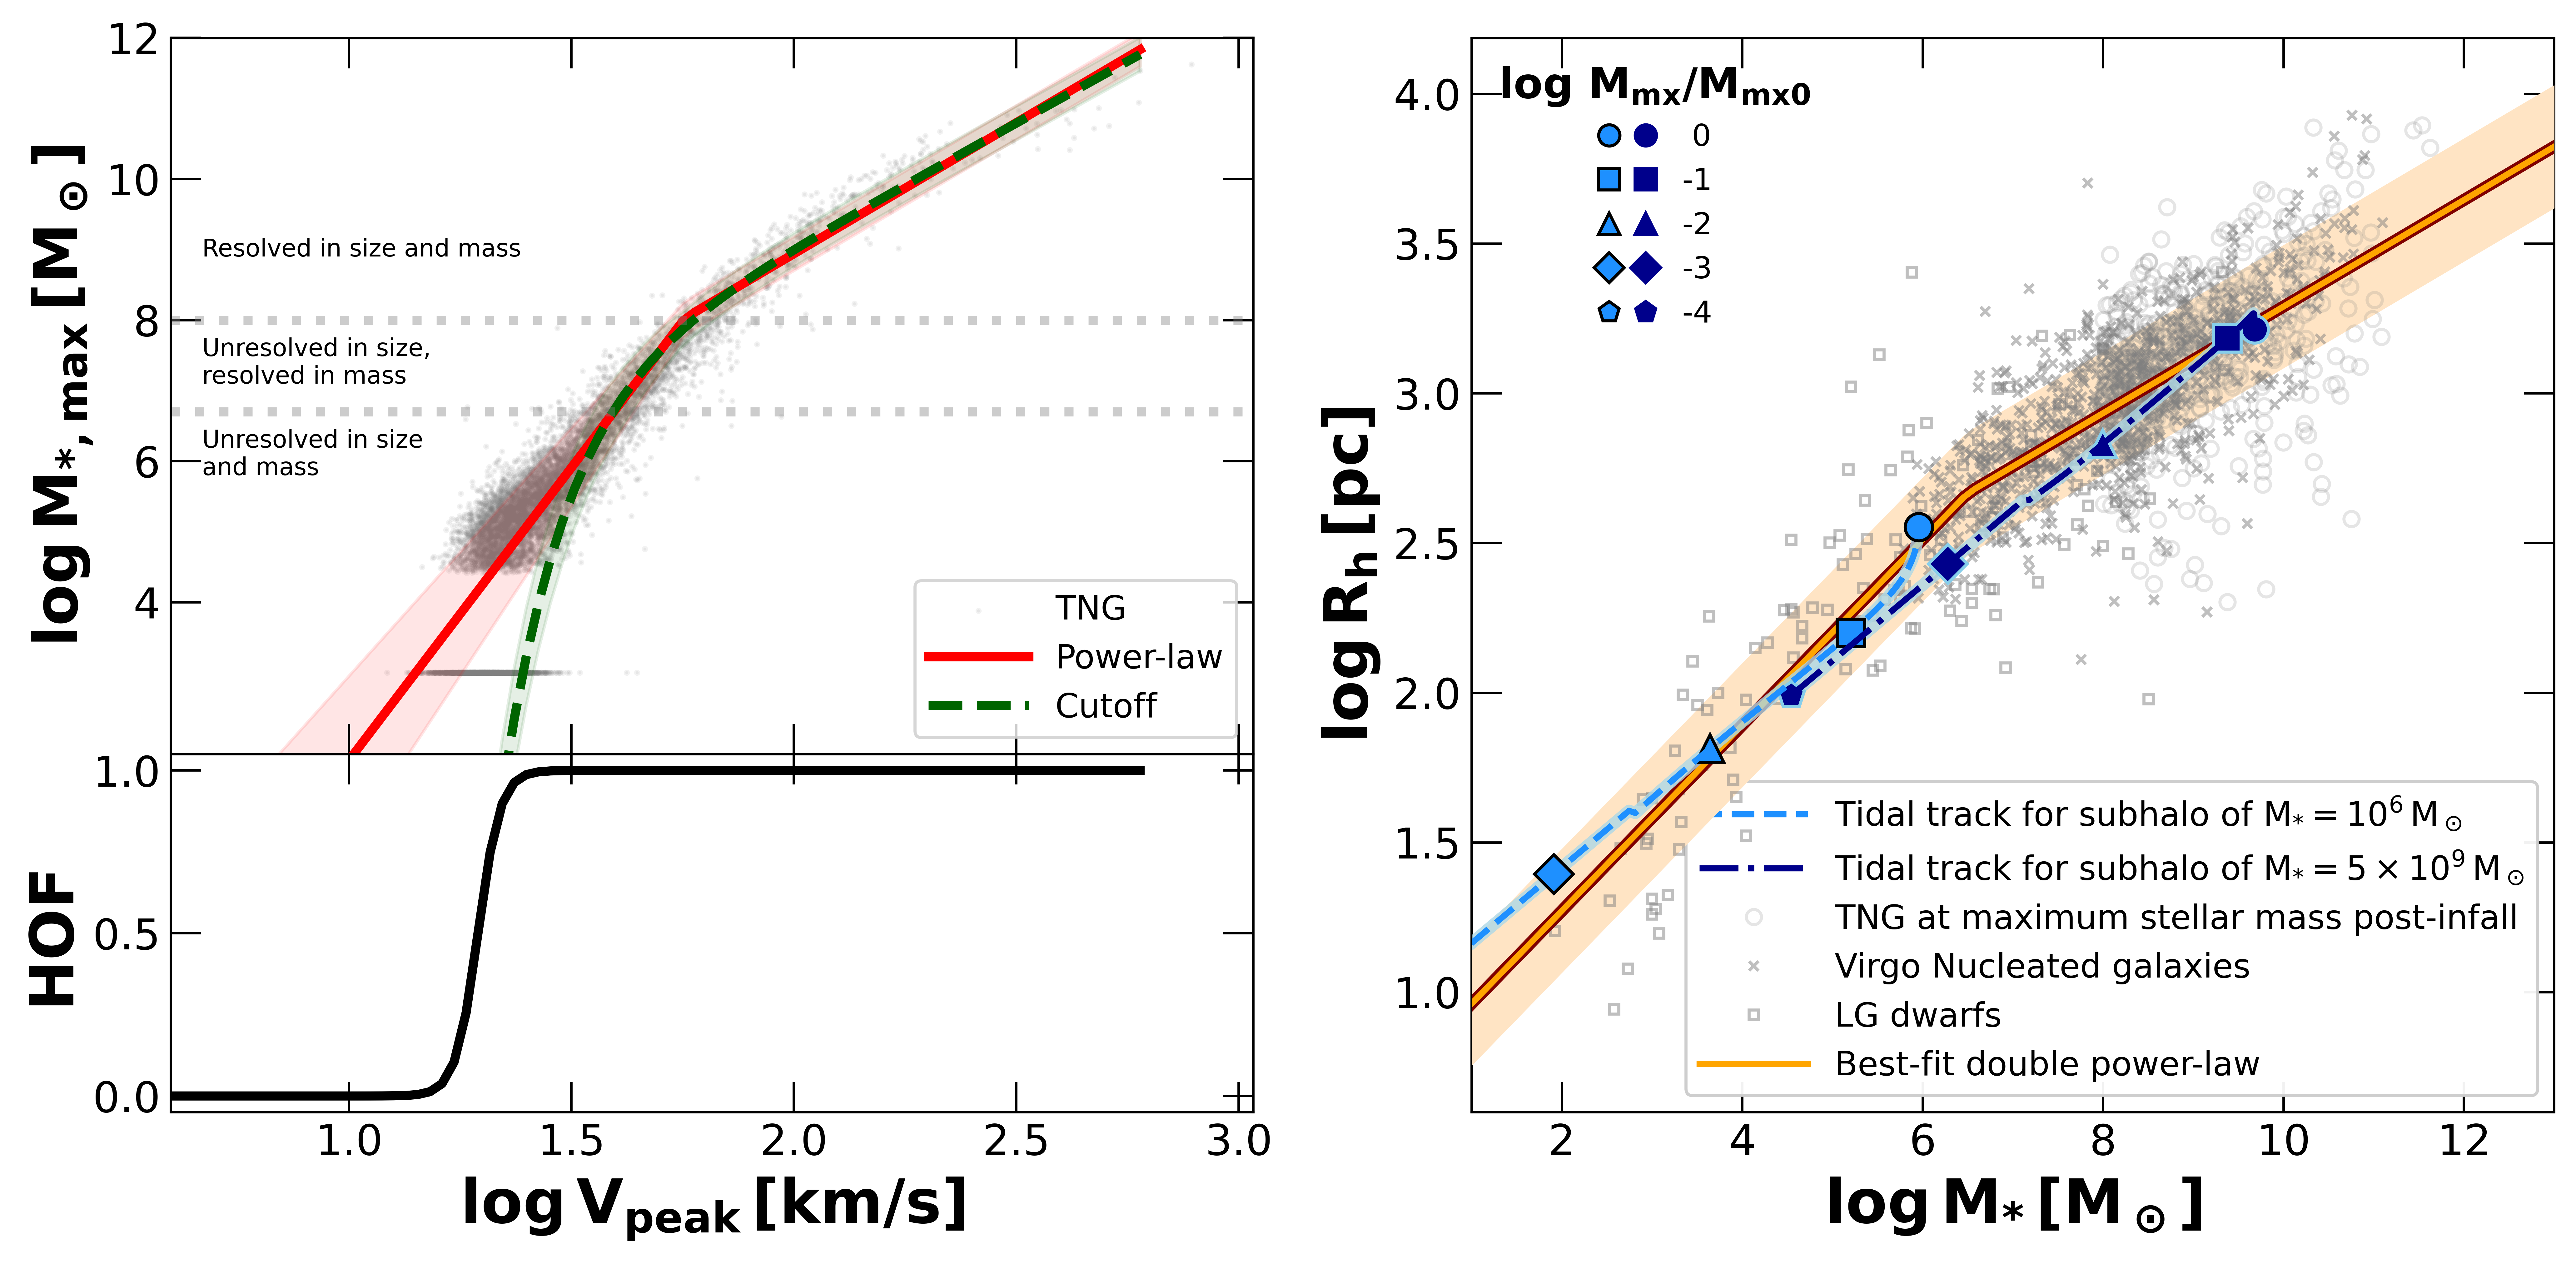

In [24]:
fig = plt.figure(figsize=(12, 6), dpi = 700)

gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])

# Create a custom layout for the left panel
gs_left = gs[:, 0].subgridspec(2, 1, height_ratios=[2, 1], hspace=0)  # Divide into 2 rows with appropriate height ratios

# Add subpanels to the left panel
ax = fig.add_subplot(gs_left[0:1, 0])  # Top panel (2/3 height)
ax3 = fig.add_subplot(gs_left[1, 0], sharex=ax)  # Bottom panel (1/3 height)

ax2 = fig.add_subplot(gs[:, 1])  # Right panel (full height)


# Here stars plotting

ax.scatter(np.log10(a4_t1_vpeak_ar), np.log10(a4_t1_mstar_max_ar1), color = 'gray', marker = 'o', s = 1, alpha = 0.1, label = 'TNG')
ax.plot(lvmax_pl, get_mstar_pl(lvmax_pl), color = 'red', label = 'Power-law')
ax.fill_between(lvmax_pl, get_mstar_pl(lvmax_pl) - get_scatter(lvmax_pl), get_mstar_pl(lvmax_pl) + get_scatter(lvmax_pl), color = 'red', alpha = 0.1)
ax.plot(lvmax_pl, get_mstar_co(lvmax_pl), color = 'darkgreen', label = 'Cutoff', ls = '--')
ax.fill_between(lvmax_pl, get_mstar_co(lvmax_pl) - get_scatter(lvmax_pl), get_mstar_co(lvmax_pl) + get_scatter(lvmax_pl), color = 'darkgreen', alpha = 0.1)
ax.set_ylabel(r'$\bf{log \, M_{*,max} \, [M_\odot]}$', fontsize = label_font)
ax3.set_xlabel(r'$\bf{log \, V_{peak} \, [km/s]}$', fontsize = label_font)  # "km/s" is a unit, typically not bold but can be left as is
ax.axhline(np.log10(5e6), ls = ':', color = 'gray', alpha = 0.4)
xtext = 0.67
ax.text(xtext, 5.8, 'Unresolved in size\nand mass', fontsize = 8)
ax.axhline(np.log10(1e8), ls = ':', color = 'gray', alpha = 0.4)
ax.text(xtext, 7.1, 'Unresolved in size,\nresolved in mass', fontsize = 8)
ax.text(xtext, 8.9, 'Resolved in size and mass', fontsize = 8)

ax.set_yticks([4, 6, 8, 10, 12])
ax.set_yticklabels([4, 6, 8, 10, 12])
ax.tick_params(axis='x', labelbottom=False)

ax.tick_params(axis='y', which = 'both', left=True, right=True, direction = 'in')
ax.tick_params(axis='x', which = 'both', direction = 'in', top = True)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_ylim(bottom = np.log10(7e1), top = 12)
ax.set_xlim(left = 0.6)
ax.legend(fontsize = 11, loc = 'lower right', handlelength = 3) 

#We will be plotting all the subhalos with at least 1e8 Msun from TNG at infall in second panel
# ax2.plot()
df_1e6 = pd.read_csv(misc_path + '1e6_tidal_tracks2.csv')
lmstar_1e6 = np.log10(df_1e6['mstar'].values)
lrh_1e6 = np.log10(df_1e6['rh'].values)
lfrem_1e6 = np.log10(df_1e6['frem'].values)
df_5e9 = pd.read_csv(misc_path + '5e9_tidal_tracks2.csv')
lmstar_5e9 = np.log10(df_5e9['mstar'].values)
lrh_5e9 = np.log10(df_5e9['rh'].values)
lfrem_5e9 = np.log10(df_5e9['frem'].values)

marker_ar = ['o', 's', '^', 'D', 'p']
for lfrem in np.array([0, -1, -2, -3, -4]):
    ix = np.argmin(np.abs(lfrem_1e6 - lfrem))
    ax2.plot(lmstar_1e6[ix], lrh_1e6[ix], marker = marker_ar[int(-lfrem)], color = 'dodgerblue', zorder = 1000, ms = 9, mec = 'black')
    ix2 = np.argmin(np.abs(lfrem_5e9 - lfrem))
    ax2.plot(lmstar_5e9[ix2], lrh_5e9[ix2], marker = marker_ar[int(-lfrem)], color = 'darkblue', zorder = 1000, ms = 9, mec = 'skyblue')

ax2.plot(lmstar_1e6, lrh_1e6, color = 'lightblue', zorder = 900, lw = 4, ls = '-', alpha = 0.8)
ax2.plot(lmstar_1e6, lrh_1e6, color = 'dodgerblue', zorder = 1000, lw = 2, ls = '--', label = r'Tidal track for subhalo of $\mathrm{M_{*} = 10^6\, M_\odot}$')
ax2.plot(lmstar_5e9, lrh_5e9, color = 'lightblue', zorder = 900, lw = 4, ls = '-', alpha = 0.8)
ax2.plot(lmstar_5e9, lrh_5e9, color = 'darkblue', zorder = 1000, lw = 2, ls = '-.', label = r'Tidal track for subhalo of $\mathrm{M_{*} = 5 \times 10^9\, M_\odot}$')

mspl_log = np.linspace(1, 13, 100)
ax2.plot(np.log10(a4_t1_mstar_max_ar[a4_t1_mstar_max_ar >= 1e8]), np.log10(1e3 * a4_t1_rh_max_ar[a4_t1_mstar_max_ar >= 1e8]), color = 'gray', marker = 'o', 
         ms = 5, alpha = 0.2, label = 'TNG at maximum stellar mass post-infall', lw = 0, zorder = 200, mfc = 'none')
plot_lg_virgo_some(ax2, alpha = 0.5, mec = 'gray', zorder = 200, lgm = 's')
# ax2.plot(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)), color = 'k', zorder = 500)
ax2.plot(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)), color = 'maroon', zorder = 450, lw = 4)
ax2.plot(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)), color = 'orange', zorder = 450, lw = 2, label = 'Best-fit double power-law')
ax2.fill_between(mspl_log, np.log10(1e3 * 10**get_lrh(mspl_log)) - 0.2, np.log10(1e3 * 10**get_lrh(mspl_log)) + 0.2, color = 'bisque', alpha = 1, zorder = 100)
ax2.set_ylabel(r'$\bf{log \,  R_{h} \,[pc]}$', fontsize = label_font)
ax2.set_xlabel(r'$\bf{log \, M_{*} \, [M_\odot]}$', fontsize = label_font)
ax2.legend(fontsize=11, handlelength=3.25, frameon=True, fancybox=True, framealpha=0.95, facecolor="white")
ax2.set_xlim(left = 1, right = 13)


# --- Custom legend for tidal track markers ---
import matplotlib.lines as mlines

# Define marker/label/color pairs for the "rows"
custom_handles = [
    [
        mlines.Line2D([], [], color='dodgerblue', marker='o', linestyle='None', markersize=7, mec = 'black'),
        mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None', markersize=7),
    ],
    [
        mlines.Line2D([], [], color='dodgerblue', marker='s', linestyle='None', markersize=7, mec = 'black'),
        mlines.Line2D([], [], color='darkblue', marker='s', linestyle='None', markersize=7),
    ],
    [
        mlines.Line2D([], [], color='dodgerblue', marker='^', linestyle='None', markersize=7, mec = 'black'),
        mlines.Line2D([], [], color='darkblue', marker='^', linestyle='None', markersize=7),
    ],
    [
        mlines.Line2D([], [], color='dodgerblue', marker='D', linestyle='None', markersize=7, mec = 'black'),
        mlines.Line2D([], [], color='darkblue', marker='D', linestyle='None', markersize=7),
    ],
    [
        mlines.Line2D([], [], color='dodgerblue', marker='p', linestyle='None', markersize=7, mec = 'black'),
        mlines.Line2D([], [], color='darkblue', marker='p', linestyle='None', markersize=7),
    ]
]
labels = [
    " 0",
    r'-1',
    r'-2',
    r'-3',
    r'-4'
]

# For each label, combine the blue and darkblue marker horizontally using a dummy container
from matplotlib.legend_handler import HandlerTuple

# Flatten each pair into a tuple for HandlerTuple
custom_handles_tuples = [(pair[0], pair[1]) for pair in custom_handles]
from matplotlib.legend import Legend
# Place this custom legend, for example in the lower left (chosen to avoid overlapping)
custom_legend = Legend(
    ax2, 
    handles=custom_handles_tuples, 
    labels=labels, 
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='upper left',  # adjust this as appropriate
    fontsize=10,
    title=r'log $\mathbf{M_{mx}/M_{mx0}}$',
    title_fontproperties={'weight': 'bold'},
    frameon=False
)
ax2.add_artist(custom_legend)  # Ensure this legend is drawn in addition to the existing one



# Here in ax3 we will be plotting the HOF

def hof(lvpeak, x0 = 1.29, x1 = 0.05):
    return 0.5 * (1 + np.tanh((lvpeak - x0) / x1)) 

ax3.plot(lvmax_pl, hof(lvmax_pl), color = 'black')
ax3.set_ylabel(r'HOF', fontsize = label_font)

plt.tight_layout()
# plt.savefig(figpath + 'FIG2.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()


# Create a grid of subplots with specified width ratios
# GridSpec allows more complex layouts
# gs = fig.add_gridspec(1, 1, width_ratios=[1, 1])

# # Add subplots to the grid
# ax1 = fig.add_subplot(gs[:, :2])  # Left half, occupying both rows
# ax2 = fig.add_subplot(gs[0, 1])  # Right half, top plot
# ax3 = fig.add_subplot(gs[1, 1], sharex=ax2) 

FoF: 0
% increase in satellites above 1e7 Msun within powerlar model: 55.43071161048689
% increase in satellites above 1e7 Msun within cutoff model: 47.752808988764045
FoF: 1
% increase in satellites above 1e7 Msun within powerlar model: 37.58169934640523
% increase in satellites above 1e7 Msun within cutoff model: 30.718954248366014
FoF: 2
% increase in satellites above 1e7 Msun within powerlar model: 49.00990099009901
% increase in satellites above 1e7 Msun within cutoff model: 46.039603960396036
[14.263622 14.263622 14.263622 13.973554 13.973554 13.973554 13.810421
 13.810421 13.810421] [2.36735592 2.37657696 2.38916608 2.13033377 2.05690485 2.2764618
 2.13353891 2.02938378 2.17026172]
Virgo m_bf, b_bf =  0.6094123685044762 -6.326999235540119
Virgo virial mass is (log Msun): 14.096588366281456
median: 148.0 and diffN: -0.09337435319315057
Fornax m_bf, b_bf =  0.7352542440833171 -7.739732699125024
Fornax virial mass is (log Msun): 13.705371149624693
median: 350.0 and diffN: 0.2068684

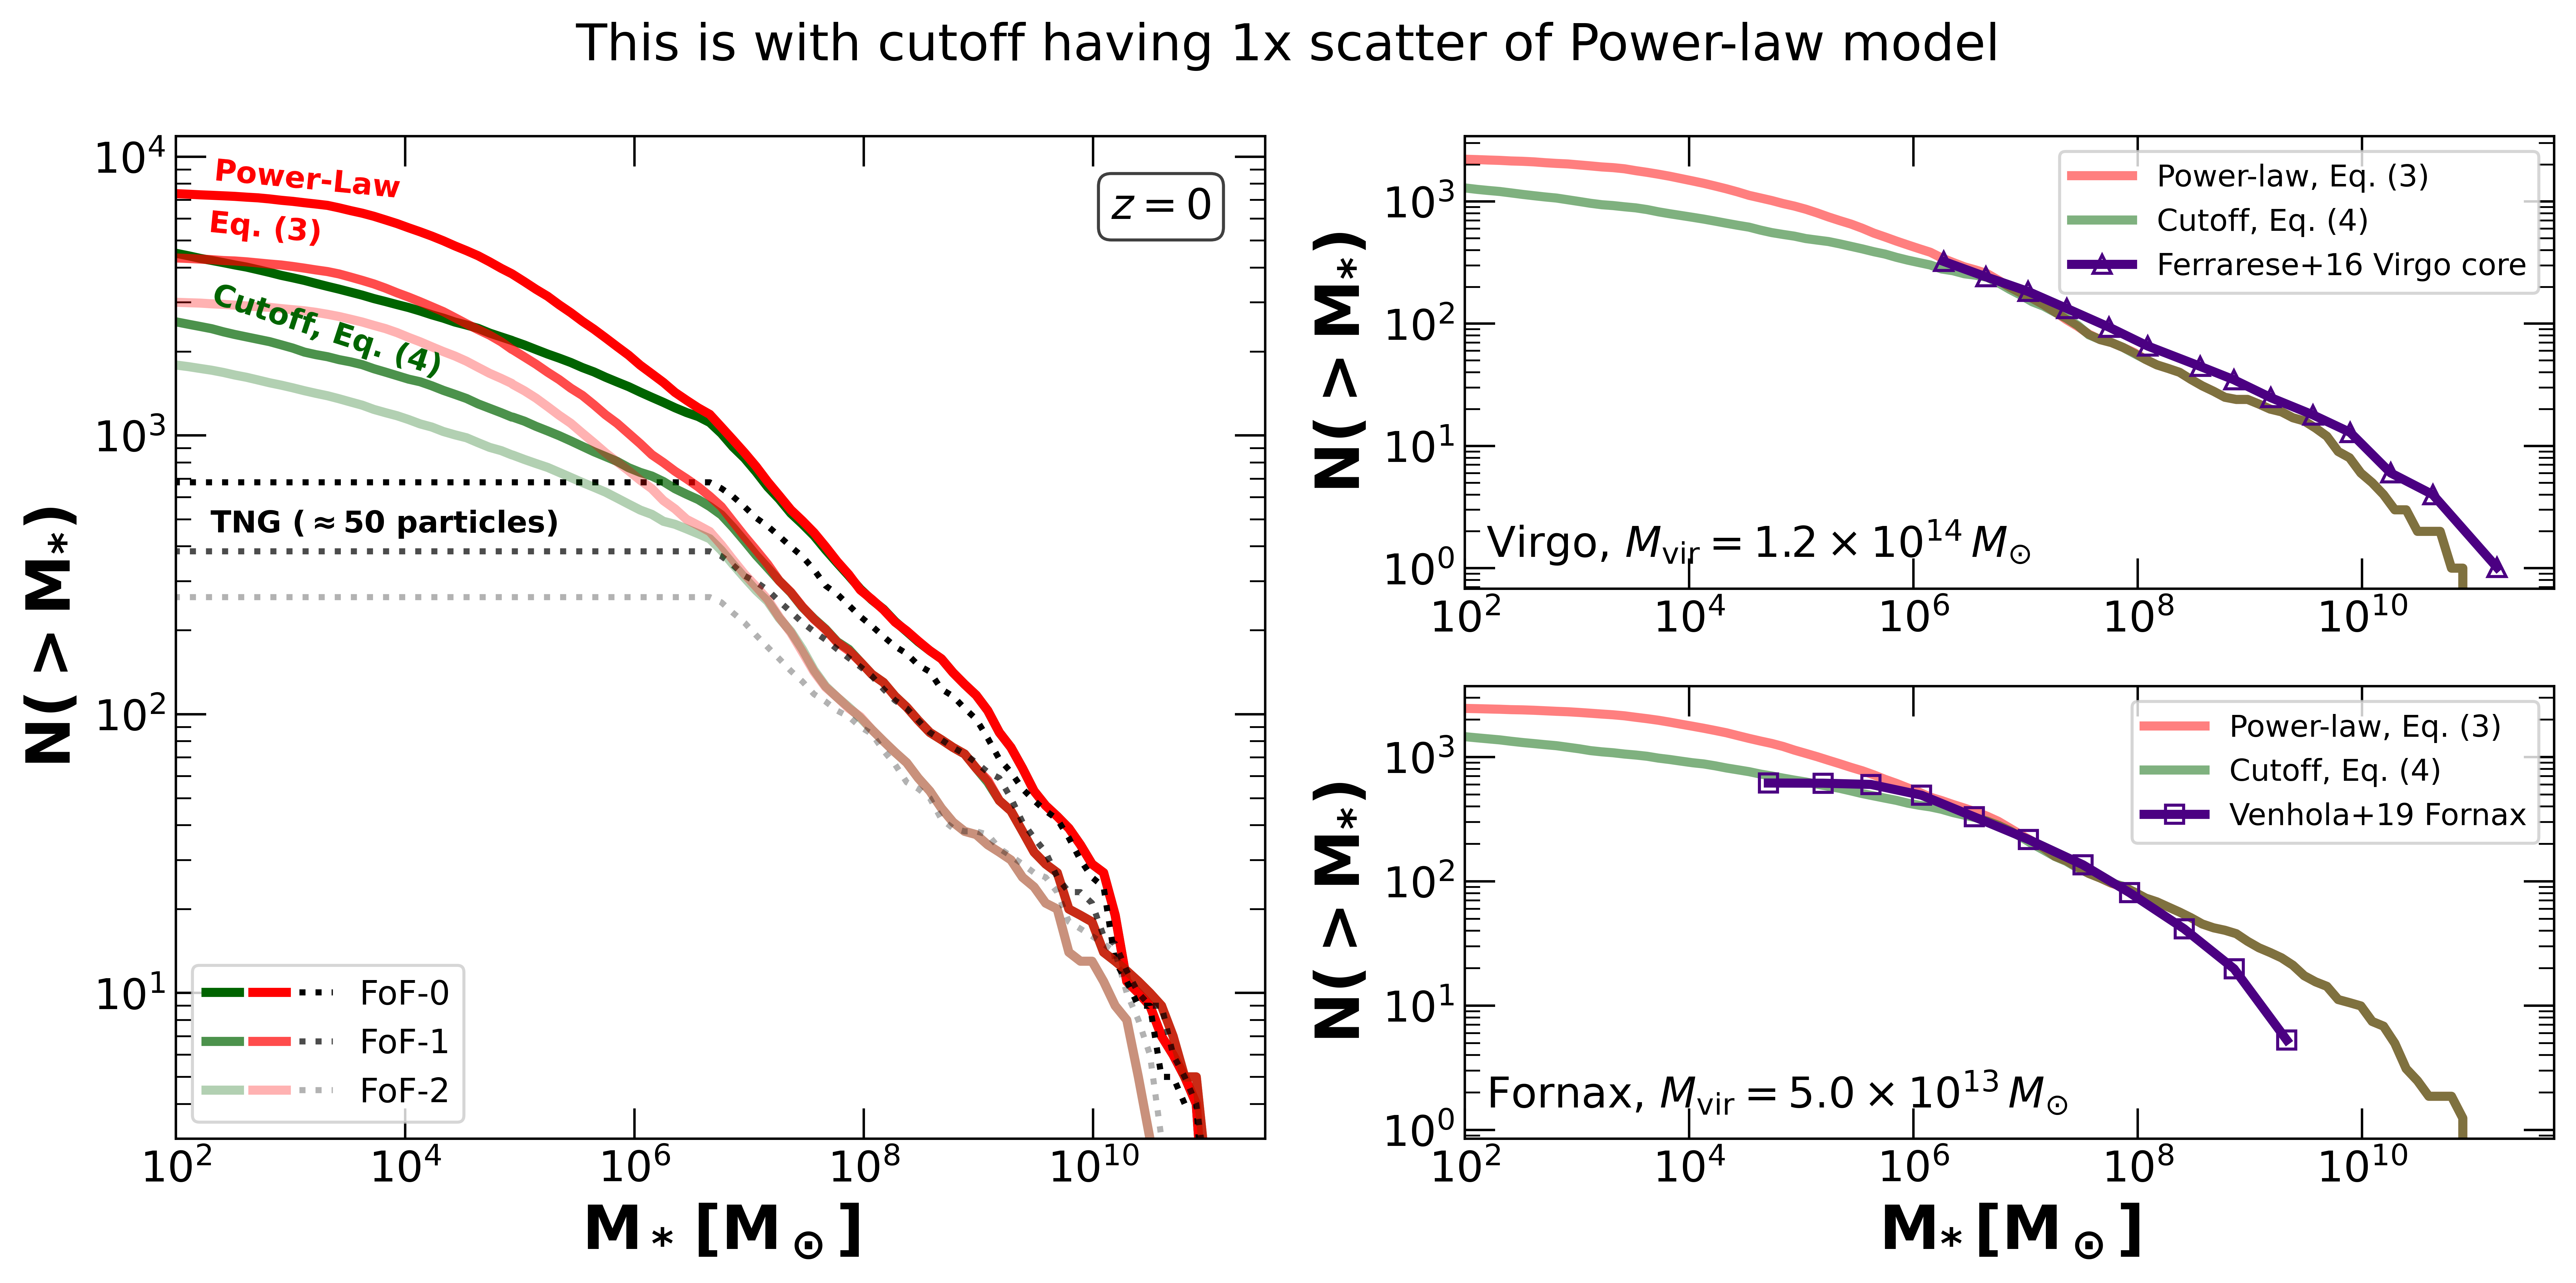

In [17]:

fig = plt.figure(figsize=(12, 6), dpi = 700)

# Create a grid of subplots with specified width ratios
# GridSpec allows more complex layouts
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])

# Add subplots to the grid
ax1 = fig.add_subplot(gs[:, 0])  # Left half, occupying both rows
ax2 = fig.add_subplot(gs[0, 1])  # Right half, top plot
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2) 

# ax1.axvline(x = 2.5e4, color = 'skyblue', ls = '-', lw = 4)
# ax1.text(2.5e4 * 5 / 8.5, 0.05, r'$\bf{\approx}$ 1 stellar particle in TNG50', color='skyblue', fontsize=12, rotation=90, va='bottom', ha='center', transform=ax1.get_xaxis_transform(), fontweight = 'bold')

if True:
    mstarpl = np.sort(np.append(np.logspace(1, 11, 100), 8.5e4))
    # fig, ax = plt.subplots(figsize = (6, 6.25))
    ls_ar = ['-.', '--', '-']
    alpha_ar = [1, 0.7, 0.3]
    

    Ntng_ar = np.zeros(0) #We will be plotting the averge value for all FoFs combined
    p1_ar = []
    p2_ar = []
    t1_ar = []

    for this_fof in [0, 1, 2]:
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos 
        Ntng_ar = np.zeros(0)
        
        if this_fof == 0:
            this_rvir = r200_0
        elif this_fof == 1:
            this_rvir = r200_1
        elif this_fof == 2:
            this_rvir = r200_2

        for (ix, ms) in enumerate(mstarpl):
            # print(len(a4_t2_mstar_pl_all), len(a4_t2_fof), len(a4_t2_xy_dist_f_ar), len(a4_t2_dist_f_ar))
            pNm_ar = np.append(pNm_ar, len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > ms) & (a4_t2_fof == this_fof) & (a4_t2_xy_dist_f_ar < this_rvir) & (a4_t2_dist_f_ar < this_rvir)]))
            pNs_ar = np.append(pNs_ar, len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > ms) &  (a4_t1_fof == this_fof) & (a4_t1_xy_dist_f_ar < this_rvir) & (a4_t1_dist_f_ar < this_rvir)]))
            cNm_ar = np.append(cNm_ar, len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > ms) & (a4_t2_fof == this_fof) & (a4_t2_xy_dist_f_ar < this_rvir) & (a4_t2_dist_f_ar < this_rvir)]))
            cNs_ar = np.append(cNs_ar, len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > ms) & (a4_t1_fof == this_fof) & (a4_t1_xy_dist_f_ar < this_rvir) & (a4_t1_dist_f_ar < this_rvir)]))
            Ntng_ar = np.append(Ntng_ar, len(a4_t1_mstar_f_ar_tng[(a4_t1_mstar_f_ar_tng > ms) & (a4_t1_mstar_f_ar_tng > 5e6) & (a4_t1_fof == this_fof) & (a4_t1_xy_dist_f_ar < this_rvir) & (a4_t1_dist_f_ar < this_rvir)]))
    
        p1, = ax1.plot(mstarpl, cNs_ar + cNm_ar, color = 'darkgreen', alpha = alpha_ar[this_fof])
        p2, = ax1.plot(mstarpl, pNs_ar + pNm_ar, color = 'red', alpha = alpha_ar[this_fof])
        t1, = ax1.plot(mstarpl, Ntng_ar, color = 'black', alpha = alpha_ar[this_fof], ls = ':', lw = 2)
        
        p1_ar = p1_ar + [p1]
        p2_ar = p2_ar + [p2]
        t1_ar = t1_ar + [t1]
        

        print('FoF:', this_fof)
        Nsats1_pl_1e7 =  len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > 1e7) & (a4_t1_fof == this_fof) ])
        Nsats2_pl_1e7 =  len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > 1e7) & (a4_t2_fof == this_fof) ])
        Nsats1_co_1e7 =  len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > 1e7) & (a4_t1_fof == this_fof) ])
        Nsats2_co_1e7 =  len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > 1e7) & (a4_t2_fof == this_fof) ])
        Nsats_tng_1e7 =  len(a4_t1_mstar_f_ar_tng[(a4_t1_mstar_f_ar_tng > 1e7) & (a4_t1_fof == this_fof) ])
        print('% increase in satellites above 1e7 Msun within powerlar model:', 100*(Nsats1_pl_1e7 + Nsats2_pl_1e7 - Nsats_tng_1e7)/Nsats_tng_1e7)
        print('% increase in satellites above 1e7 Msun within cutoff model:', 100*(Nsats1_co_1e7 + Nsats2_co_1e7 - Nsats_tng_1e7)/Nsats_tng_1e7)
        # print('Nsats above 1e7 Msun for powerlaw Type-2s:', len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > 1e7) & (a4_t2_fof == this_fof) ]))
        # print('Nsats above 1e7 Msun for cutoff Type-1s:', len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > 1e7) & (a4_t1_fof == this_fof) ]))
        # print('Nsats above 1e7 Msun for cutoff Type-2s:', len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > 1e7) & (a4_t2_fof == this_fof) ]))
        # # print('Nsats above 1e9 Msun for cutoff:', len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > 1e9) & (a4_t2_fof == this_fof) ]) + len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > 1e9) & (a4_t1_fof == this_fof) ]))
        # print('Nsats above 1e7 Msun for TNG:', len(a4_t1_mstar_f_ar_tng[(a4_t1_mstar_f_ar_tng > 1e7) & (a4_t1_fof == this_fof) ]))
        # print('Nsats above 1e5 Msun for powerlaw:', len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > 1e5) & (a4_t2_fof == this_fof) ]) + len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > 1e5) & (a4_t1_fof == this_fof) ]))
        # print('Nsats above 1e5 Msun for cutoff:', len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > 1e5) & (a4_t2_fof == this_fof) ]) + len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > 1e5) & (a4_t1_fof == this_fof) ]))
        # print('Nsats above 1e5 Msun for TNG:', len(a4_t1_mstar_f_ar_tng[(a4_t1_mstar_f_ar_tng > 1e5) & (a4_t1_fof == this_fof) ]))
        # ax1.legend([p1, p2], ['Cutoff', 'Power law'], fontsize = 8)

        # ax1.plot([1e1, 2e1], [1, 2], alpha = alpha_ar[this_fof], color = 'black', label = f'FoF{this_fof}') #This is just for the legend

    # NTNGpl = (Ntng_ar[:int(len(Ntng_ar)/3)] + Ntng_ar[int(len(Ntng_ar)/3) : int(2 * len(Ntng_ar)/3)] + Ntng_ar[int(2 * len(Ntng_ar)/3) :])/3.
    # tng1, = ax1.plot(mstarpl[::4], NTNGpl[::4], color = 'black', marker = 'o', label = 'TNG average for FoFs', markersize = 6, lw = 0)
    ax1.annotate('Power-Law\nEq. (3)', xy = (2e2, 6.5e3), xytext = (2e2, 6.5e3), rotation=-5.5, 
                    color='red', fontsize=10, rotation_mode='anchor', fontweight='bold', linespacing=2)
    ax1.annotate(r'Cutoff, Eq. (4)', xy = (2e2, 3e3), xytext = (2e2, 3e3), rotation=-18, 
                    color='darkgreen', fontsize=10, rotation_mode='anchor', fontweight = 'bold')
    ax1.annotate(r'TNG ($\mathbf{\approx 50}$ particles)', xy = (2e2, 4.5e2), xytext = (2e2, 4.5e2), rotation=0, 
                    color='black', fontsize=10, rotation_mode='anchor', fontweight = 'bold')
    ax1.legend([(p1_ar[0], p2_ar[0],  t1_ar[0]), (p1_ar[1], p2_ar[1],  t1_ar[1]), (p1_ar[2], p2_ar[2],  t1_ar[2])], ['FoF-0', 'FoF-1', 'FoF-2'], fontsize = 11, handler_map={tuple: HandlerTuple(ndivide=None)}, 
               loc = 'lower left', handlelength = 3.8)
    ax1.set_xlabel(r'$\mathbf{M_*\,{[M_\odot]}}$', fontsize = label_font)
    ax1.set_ylabel(r'$\mathbf{N(>M_{*})}$', fontsize = label_font)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(left = 1e2)
    ax1.set_ylim(bottom = 3)
    ax1.tick_params(axis='y', which = 'both', left=True, right=True, direction = 'in')
    ax1.tick_params(axis='x', which = 'both', direction = 'in')
    ax1.text(0.95, 0.95, r'$z = 0$', ha='right', va='top', transform=ax1.transAxes,
             bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white', alpha=0.75))
    
    # ax.set_title('FoF'+str(fof_no))

if True: #This is for the second panel
    rcore_virgo = 309 #This is assumed to be the core radius temporarily


    mstarpl = np.logspace(1, 11, 100)

    # rvir_fornax = 700 #kpc

    # fig, ax = plt.subplots(figsize = (6, 6.25))
    ls_ar = ['-.', '--', '-']
    pNm_ar = np.zeros(0) #shmf for merged subhalos
    pNs_ar = np.zeros(0) #shmf for surviving subhalos 
    cNm_ar = np.zeros(0) #shmf for merged subhalos
    cNs_ar = np.zeros(0) #shmf for surviving subhalos
    mstar_match = 1e7 #This is the stellar mass where we try to match the fornax and the model
    N_fitting = np.zeros(0)
    mvir_ar = np.array([m200_0, m200_0, m200_0, m200_1, m200_1, m200_1, m200_2, m200_2, m200_2])



    for this_fof in [0, 1, 2]:
        for projection in [0, 1, 2]:
            if projection == 0:
                pm_proj_dist = a4_t2_xy_dist_f_ar
                ps_proj_dist = a4_t1_xy_dist_f_ar
                cm_proj_dist = a4_t2_xy_dist_f_ar
                cs_proj_dist = a4_t1_xy_dist_f_ar
            elif projection == 1:
                pm_proj_dist = a4_t2_yz_dist_f_ar
                ps_proj_dist = a4_t1_yz_dist_f_ar
                cm_proj_dist = a4_t2_yz_dist_f_ar
                cs_proj_dist = a4_t1_yz_dist_f_ar
            elif projection == 2:
                pm_proj_dist = a4_t2_xz_dist_f_ar
                ps_proj_dist = a4_t1_xz_dist_f_ar
                cm_proj_dist = a4_t2_xz_dist_f_ar
                cs_proj_dist = a4_t1_xz_dist_f_ar


            N_fitting = np.append(N_fitting, len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > mstar_match) & (a4_t1_fof == this_fof) & (ps_proj_dist <= rcore_virgo)]))


            for (ix, ms) in enumerate(mstarpl):
                pNm_ar = np.append(pNm_ar, len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > ms) & (a4_t2_fof == this_fof) & (pm_proj_dist <= rcore_virgo)]))
                pNs_ar = np.append(pNs_ar, len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > ms) &  (a4_t1_fof == this_fof) & (ps_proj_dist <= rcore_virgo) ]))
                cNm_ar = np.append(cNm_ar, len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > ms) & (a4_t2_fof == this_fof) & (cm_proj_dist <= rcore_virgo) ]))
                cNs_ar = np.append(cNs_ar, len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > ms) & (a4_t1_fof == this_fof) & (cs_proj_dist <= rcore_virgo) ]))
                
            
    print(np.log10(mvir_ar), np.log10(N_fitting))
    m_bf, b_bf = np.polyfit(np.log10(mvir_ar), np.log10(N_fitting), 1) #This returns slope and intercept
    print('Virgo m_bf, b_bf = ', m_bf, b_bf)
    Nvirg_1e7 = 183.5 #Number of galaxies above 1e7 Msun in Fornax
    lmvir_virgo_calc = ((np.log10(Nvirg_1e7) - b_bf)/m_bf) #These are the number of galaxies above 1e7 Msun in Fornax
    print(f'Virgo virial mass is (log Msun): {lmvir_virgo_calc}')

    diffN = np.log10(np.median(N_fitting)) - np.log10(Nvirg_1e7)
    print(f'median: {np.median(N_fitting)} and diffN: {diffN}')
    
    ax2.plot(mstarpl, get_med_values(pNs_ar + pNm_ar, 9), color = 'red', label = 'Power-law, Eq. (3)', alpha = 0.5, ls = '-')
    ax2.plot(mstarpl, get_med_values(cNs_ar + cNm_ar, 9), color = 'darkgreen', label = 'Cutoff, Eq. (4)', alpha = 0.5, ls = '-')
    # ax2.fill_between(mstarpl, get_quantiles(cNs_ar + cNm_ar, 9)[0], get_quantiles(cNs_ar + cNm_ar, 9)[1], color = 'darkgreen', alpha = 0.3)
    # ax2.fill_between(mstarpl, get_quantiles(pNs_ar + pNm_ar, 9)[0], get_quantiles(pNs_ar + pNm_ar, 9)[1], color = 'red', alpha = 0.3)
    ax2.plot(10**fmstar, fngal_cum, color = 'indigo', marker = '^', label = 'Ferrarese+16 Virgo core', markersize = 6, markerfacecolor = 'none')
    ax2.legend(fontsize = 10)
    # ax2.set_xlabel(r'$M_{\bigstar}\,\rm{(M_\odot)}$')
    ax2.set_ylabel(r'$\mathbf{N(>M_{*})}$', fontsize = label_font)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlim(left = 1e2)
    ax2.tick_params(axis='y', which = 'both', left=True, right=True, direction = 'in')
    ax2.tick_params(axis='x', which = 'both', direction = 'in')
    ax2.text(0.02, 0.05, r'Virgo, $M_{\rm{vir}} = 1.2 \times 10^{14}\,M_{\odot}$', ha = 'left', va = 'bottom', transform=ax2.transAxes)


if True: #This is for the third panel
    mstarpl = np.logspace(1, 11, 100)

    rvir_fornax = 700 #kpc
    
    # fig, ax = plt.subplots(figsize = (6, 6.25))
    ls_ar = ['-.', '--', '-']
    pNm_ar = np.zeros(0) #shmf for merged subhalos
    pNs_ar = np.zeros(0) #shmf for surviving subhalos 
    cNm_ar = np.zeros(0) #shmf for merged subhalos
    cNs_ar = np.zeros(0) #shmf for surviving subhalos
    mstar_match = 1e7 #This is the stellar mass where we try to match the fornax and the model
    N_fitting = np.zeros(0)
    mvir_ar = np.array([m200_0, m200_0, m200_0, m200_1, m200_1, m200_1, m200_2, m200_2, m200_2])

    for this_fof in [0, 1, 2]:
        for projection in [0, 1, 2]:
            if projection == 0:
                pm_proj_dist = a4_t2_xy_dist_f_ar
                ps_proj_dist = a4_t1_xy_dist_f_ar
                cm_proj_dist = a4_t2_xy_dist_f_ar
                cs_proj_dist = a4_t1_xy_dist_f_ar
            elif projection == 1:
                pm_proj_dist = a4_t2_yz_dist_f_ar
                ps_proj_dist = a4_t1_yz_dist_f_ar
                cm_proj_dist = a4_t2_yz_dist_f_ar
                cs_proj_dist = a4_t1_yz_dist_f_ar
            elif projection == 2:
                pm_proj_dist = a4_t2_xz_dist_f_ar
                ps_proj_dist = a4_t1_xz_dist_f_ar
                cm_proj_dist = a4_t2_xz_dist_f_ar
                cs_proj_dist = a4_t1_xz_dist_f_ar

            N_fitting = np.append(N_fitting, len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > mstar_match) & (a4_t1_fof == this_fof) & (ps_proj_dist <= rvir_fornax)]))

            for (ix, ms) in enumerate(mstarpl):
                pNm_ar = np.append(pNm_ar, len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > ms) & (a4_t2_fof == this_fof) & (pm_proj_dist <= rvir_fornax)]))
                pNs_ar = np.append(pNs_ar, len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > ms) &  (a4_t1_fof == this_fof) & (ps_proj_dist <= rvir_fornax) ]))
                cNm_ar = np.append(cNm_ar, len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > ms) & (a4_t2_fof == this_fof) & (cm_proj_dist <= rvir_fornax) ]))
                cNs_ar = np.append(cNs_ar, len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > ms) & (a4_t1_fof == this_fof) & (cs_proj_dist <= rvir_fornax) ]))
    
    #We now have to fit a straight line to log N_fitting vs log mvir_ar
    m_bf, b_bf = np.polyfit(np.log10(mvir_ar), np.log10(N_fitting), 1) #This returns slope and intercept
    print('Fornax m_bf, b_bf = ', m_bf, b_bf)
    Nforn_1e7 = 217.37 #Number of galaxies above 1e7 Msun in Fornax
    lmvir_fornax_calc = ((np.log10(Nforn_1e7) - b_bf)/m_bf) #These are the number of galaxies above 1e7 Msun in Fornax
    print(f'Fornax virial mass is (log Msun): {lmvir_fornax_calc}')

    diffN = np.log10(np.median(N_fitting)) - np.log10(Nforn_1e7)
    print(f'median: {np.median(N_fitting)} and diffN: {diffN}')
    # dif
    # fN = 0



    ax3.plot(mstarpl, 10**(np.log10(get_med_values(pNs_ar + pNm_ar, 9)) - diffN), color = 'red', label = 'Power-law, Eq. (3)', alpha = 0.5, ls = '-')
    ax3.plot(mstarpl, 10**(np.log10(get_med_values(cNs_ar + cNm_ar, 9)) - diffN), color = 'darkgreen', label = 'Cutoff, Eq. (4)', alpha = 0.5, ls = '-')
    # ax.fill_between(mstarpl, get_quantiles(cNs_ar + cNm_ar, 9)[0] - diffN, get_quantiles(cNs_ar + cNm_ar, 9)[1] - diffN, color = 'darkgreen', alpha = 0.3)
    # ax.fill_between(mstarpl, get_quantiles(pNs_ar + pNm_ar, 9)[0] - diffN, get_quantiles(pNs_ar + pNm_ar, 9)[1] - diffN, color = 'red', alpha = 0.3)
    ax3.plot(10**vmstar, vngal_cum, color = 'indigo', marker = 's', label = 'Venhola+19 Fornax', markersize = 6, markerfacecolor = 'none')
    # for jx in range(len(sigma_pl_ar) + 1): #+2 because we also need to plot without any surface brightness limits
    # pNm_ar = np.zeros(0) #shmf for merged subhalos
    # pNs_ar = np.zeros(0) #shmf for surviving subhalos 
    # cNm_ar = np.zeros(0) #shmf for merged subhalos
    # cNs_ar = np.zeros(0) #shmf for surviving subhalos 
    # Ntng_ar = np.zeros(0)


    # for (ix, ms) in enumerate(mstarpl):
    #     pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmmstar_all > ms) & (pmfof == 0) & (pmxydist_f_ar < rvir_fornax)]))
    #     pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psmstar_all > ms) &  (psfof == 0) & (psxydist_f_ar < rvir_fornax)]))
    #     cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > ms) & (cmfof == 0) & (cmxydist_f_ar < rvir_fornax)]))
    #     cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > ms) & (csfof == 0) & (csxydist_f_ar < rvir_fornax)]))
    #     # Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[psmstar_f_ar_tng > ms]))

    # fig, ax = plt.subplots(figsize = (6, 6.25))
    
    # # ax.plot(mstarpl, Ns_ar, color = 'darkgreen', label = 'Model Surviving', alpha = 0.5)
    # ax.plot(mstarpl, cNs_ar + cNm_ar, color = 'darkgreen', label = 'Cutoff', alpha = 0.5)
    # ax.plot(mstarpl, pNs_ar + pNm_ar, color = 'red', label = 'Power law', alpha = 0.5)
    # plot_sachi(ax)
    # ax.plot(mstarpl, Ntng_ar, color = 'blue', label = 'TNG surviving', alpha = 0.5)
    ax3.legend(fontsize = 10)
    ax3.set_xlabel(r'$\mathbf{M_{ *}\,{[M_\odot]}}$', fontsize = label_font)
    ax3.set_ylabel(r'$\mathbf{N(>M_{ *})}$', fontsize = label_font)
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_xlim(left = 1e2)
    ax3.tick_params(axis='y', which = 'both', left=True, right=True, direction = 'in')
    ax3.tick_params(axis='x', which = 'both', direction = 'in')
    ax3.text(0.02, 0.05, r'Fornax, $M_{\rm{vir}} = 5.0 \times 10^{13}\,M_{\odot}$', ha = 'left', va = 'bottom', transform=ax3.transAxes)
        # ax3
        

    
fig.suptitle('This is with cutoff having 1x scatter of Power-law model')    
    
    
plt.tight_layout()
# plt.savefig(this_fof_plotppath + 'fig5.png')
# plt.savefig(figpath + 'FIG6.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()
    # plt.savefig(this_fof_plotppath + '3d_mass_fn.png')





16823
Length of cmstar: 10519
0.0 69.0


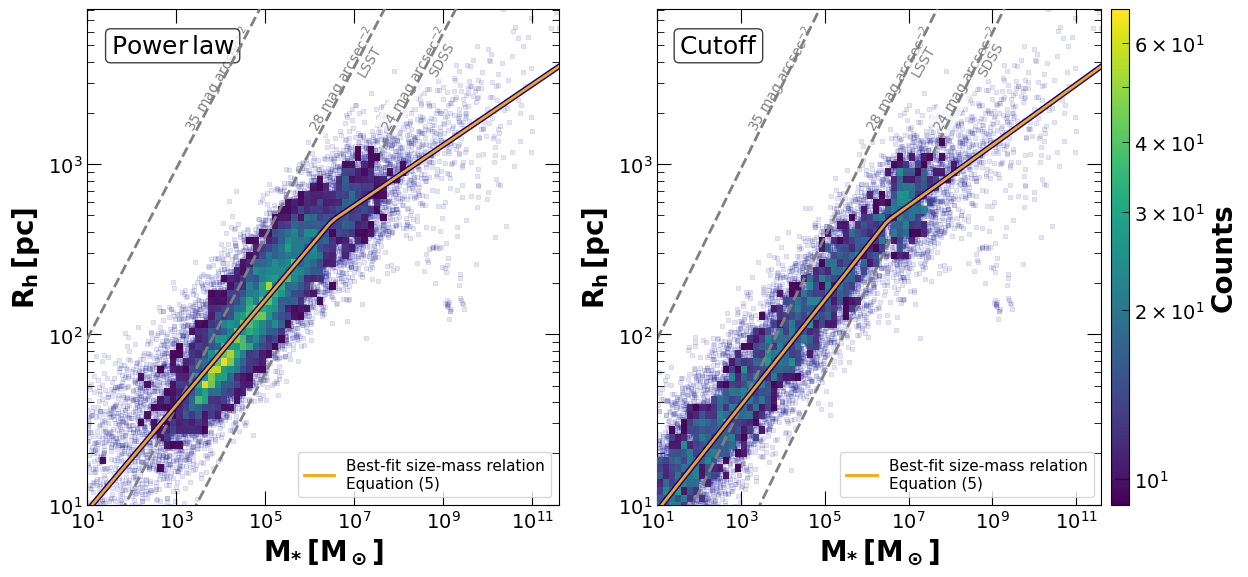

In [26]:
alpha_points = 0.1
size_points = 7.5
def get_line_of_constant_surfb(mstar, S):
    '''
    This is to plot the line of constant surface brightness
    mstar: Stellar mass
    S: Surface brightness

    Returns:
    R: Half light radius in pc
    '''
    logR = -(1/5.)*(4.83+21.57-2.5*np.log10(mstar)+2.5*np.log10(np.pi)-S)
    return 10**logR

def inverse_get_line_of_constant_surfb(R, S):
    '''
    Inverse function of get_line_of_constant_surfb
    R: Half light radius in pc
    S: Surface brightness

    Returns:
    mstar: Stellar mass
    '''
    def equation(mstar):
        return R - get_line_of_constant_surfb(mstar, S)

    mstar_guess = 1e3  # Initial guess for mstar
    mstar_solution = fsolve(equation, mstar_guess)
    return mstar_solution[0]

import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create figure and two subplots
fig, (ax2, ax) = plt.subplots(nrows=1, ncols=2, figsize=(12.7, 6))

mspl_log = np.linspace(1, 13, 100)
# plot_lg_virgo(ax)
# plot_lg_virgo(ax2)
a4_mstar_co_all = np.append(a4_t1_mstar_co_all, a4_t2_mstar_co_all)

# ax.scatter(csmstar_all[csix], np.array(csrh_all[csix]) * 1e3, marker = 's', fc = 'darkgreen', alpha = alpha_points, s = size_points, label = 'Survived', zorder = 200, edgecolor = 'darkgreen', linewidth = 0.7)
# ax.scatter(cmmstar_all[cmix], np.array(cmrh_all[cmix]) * 1e3, marker = 's', fc = 'purple', alpha = alpha_points, s = size_points, label = 'Merged', zorder = 200, edgecolor = 'purple', linewidth = 0.7)

cmstar = np.append(a4_t1_mstar_co_all, a4_t2_mstar_co_all) #msun, THis is all the subhalos in the cutoff model
crh = np.append(a4_t1_rh_co_all, a4_t2_rh_co_all) * 1e3 #kpc, This is rh of all the subhalos in the cutoff model
# cmstar = cmstar[crh > 0]
# crh = crh[crh > 0]

# Check for NaNs, infinite values, or negative values in cmstar and crh arrays
print(len(cmstar))
condition = np.isfinite(cmstar) & (cmstar > 10) & np.isfinite(crh) & (crh > 0)
cmstar = cmstar[condition]
crh = crh[condition]

print('Length of cmstar:', len(cmstar))

pmstar = np.append(a4_t1_mstar_pl_all, a4_t2_mstar_pl_all)
prh = np.append(a4_t1_rh_pl_all, a4_t2_rh_pl_all) * 1e3
# pmstar = pmstar[prh > 0]
# prh = prh[prh > 0]

# Check for NaNs, infinite values, or negative values in pmstar and prh arrays
condition = np.isfinite(pmstar) & (pmstar > 10) & np.isfinite(prh) & (prh > 0)
pmstar = pmstar[condition]
prh = prh[condition]

Nbins = 75

y_space = np.logspace(np.log10(min(crh)), np.log10(max(crh)), Nbins)
x_space = np.logspace(np.log10(min(cmstar)), np.log10(max(cmstar)), Nbins)

y_space1 = np.logspace(np.log10(min(prh)), np.log10(max(prh)), Nbins)
x_space1 = np.logspace(np.log10(min(pmstar)), np.log10(max(pmstar)), Nbins)

hist1, _, _ = np.histogram2d(cmstar, crh, bins=(x_space, y_space))
hist2, _, _ = np.histogram2d(pmstar, prh, bins=(x_space1, y_space1))

vmin = min(hist1.min(), hist2.min())
vmax = max(hist1.max(), hist2.max())

print(vmin, vmax)
vmin = 9
# vmax = 75

ax.scatter(cmstar, crh, marker = 's', fc = 'darkblue', alpha = alpha_points, s = size_points, zorder = 0, edgecolor = 'darkblue', linewidth = 0.7)
# “im1” - log normalization
_, _, _, im1 = ax.hist2d(
    cmstar, crh, bins=(x_space1, y_space1),
    cmin = vmin, norm = 'log', zorder = 100,
    vmin = vmin, vmax = vmax, alpha = 0.95, cmax = vmax
)
ax.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'darkblue', zorder = 200, lw = 4)
ax.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'orange', zorder = 200, lw = 2, label = 'Best-fit size-mass relation\nEquation (5)')
top_data = ax.get_ylim()[1]
right_data = ax.get_xlim()[1]
ax.set_xlim(left = 1e1, right = right_data)
ax.set_ylim(bottom = 10, top = top_data)
ax.legend(fontsize = 11, loc = 'lower right')

# ax2.scatter(psmstar_all[psix], np.array(psrh_all[psix]) * 1e3, marker = 's', fc = 'darkgreen', alpha = alpha_points, s = size_points, label = 'Survived', zorder = 200, edgecolor = 'darkgreen', linewidth = 0.7)
# ax2.scatter(pmmstar_all[pmix], np.array(pmrh_all[pmix]) * 1e3, marker = 's', fc = 'purple', alpha = alpha_points, s = size_points, label = 'Merged', zorder = 200, edgecolor = 'purple', linewidth = 0.7)

ax2.scatter(pmstar, prh, marker = 's', fc = 'darkblue', alpha = alpha_points, s = size_points, zorder = 0, edgecolor = 'darkblue', linewidth = 0.7)

# “im2” - linear normalization
_, _, _, im2 = ax2.hist2d(
    pmstar, prh, bins=(x_space1, y_space1),
    cmin = vmin, norm = 'linear', zorder = 100,
    vmin = vmin, vmax = vmax, alpha = 0.95, cmax = vmax
)
ax2.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'darkblue', zorder = 200, lw = 4)
ax2.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'orange', zorder = 200, lw = 2, label = 'Best-fit size-mass relation\nEquation (5)')
top_data2 = ax2.get_ylim()[1]
right_data2 = ax2.get_xlim()[1]
ax2.set_xlim(left = 1e1, right = right_data2)
ax2.set_ylim(bottom = 10, top = top_data2)
ax2.legend(fontsize = 11, loc = 'lower right')
if True: 
    #This section is for lines of constant surface brightness
    angle = 60
    lw = 2
    yval = 0.18*top_data
    ax.annotate(r'24 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 24), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 24), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))
    ax.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 24), ls = '--', color = 'gray', zorder = 50, lw = 2)

    yval2 = 0.38 * top_data
    xval2 = inverse_get_line_of_constant_surfb(yval2, 24) * 2.5
    ax.annotate(r'SDSS', xy = (xval2, yval2), xytext = (xval2, 1.05* yval2), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))

    ax.annotate(r'28 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 28), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 28), 1.05* yval), rotation=angle, color='gray', fontsize=10, rotation_mode='anchor', 
    bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))

    ax.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 28), ls = '--', color = 'gray', lw = 2, zorder = 100)

    xval3 = inverse_get_line_of_constant_surfb(yval2, 28) * 2.5
    ax.annotate(r'LSST', xy = (xval3, yval2), xytext = (xval3, 1.05* yval2), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))

    ax.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 35), ls = '--', color = 'gray', lw = 2)
    ax.annotate(r'35 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 35), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 35), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor')

    # yval = 0.21*top_data2
    ax2.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 24), ls = '--', color = 'gray', zorder = 50, lw = 2)
    ax2.annotate(r'24 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 24), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 24), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))

    ax2.annotate(r'SDSS', xy = (xval2, yval2), xytext = (xval2, 1.05* yval2), rotation=angle, color='gray', fontsize=10, rotation_mode='anchor', bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))

    ax2.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 28), ls = '--', color = 'gray', lw = 2, zorder = 100)
    ax2.annotate(r'28 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 28), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 28), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor', bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))
    ax2.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 35), ls = '--', color = 'gray', lw = 2, zorder = 100)

    xval3 = inverse_get_line_of_constant_surfb(yval2, 28) * 2.5
    ax2.annotate(r'LSST', xy = (xval3, yval2), xytext = (xval3, 1.05* yval2), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))

    ax2.annotate(r'35 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 35), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 35), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor')

# plot_lg_virgo_some(ax, alpha = 0.2)
# plot_lg_virgo_some(ax2, alpha = 0.2)

# # Example usage:
# R = 100  # Half light radius in pc
# S = 25  # Surface brightness
# mstar_inverse = inverse_get_line_of_constant_surfb(R, S)
# print(mstar_inverse)
ax.set_xlabel(r'$\mathbf{M_{ *}\,{[M_\odot]}}$', fontsize = label_font)
ax.set_ylabel(r'$\mathbf{R_{{h}}\, [pc]}$', fontsize = label_font)
ax.text(
    0.05, 0.95, 
    r'$\mathrm{Cutoff}$', 
    ha='left', va='top', 
    transform=ax.transAxes, 
    fontsize=(label_font - 2),
    bbox=dict(boxstyle='round,pad=0.2', edgecolor='black', facecolor='white', alpha=0.75)
)
# ax.legend(fontsize = 8, loc = 'lower right')
ax.tick_params(axis='both', which = 'both', left=True, right=True, bottom = True, top = True, direction = 'in')

ax2.set_xlabel(r'$\mathbf{M_{ *}\,{[M_\odot]}}$', fontsize = label_font)
ax2.set_ylabel(r'$\mathbf{R_{{h}} \,[pc]}$', fontsize = label_font)
ax2.text(
    0.05, 0.95, 
    r'$\mathrm{Power\,law}$', 
    ha='left', va='top', 
    transform=ax2.transAxes, 
    fontsize=(label_font - 2),
    bbox=dict(boxstyle='round,pad=0.2', edgecolor='black', facecolor='white', alpha=0.75)
)
# ax2.legend(fontsize = 8, loc = 'lower right')
ax2.tick_params(axis='both', which = 'both', left=True, right=True, bottom = True, top = True, direction = 'in')

ax.set_xscale('log')
ax.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yscale('log')

# Add a combined colorbar to the right of both subplots for im1 and im2 combined

# To ensure the colorbar is shared and visually covers both subplots,
# use the figure colorbar with an axes divider for better layout.
from mpl_toolkits.axes_grid1 import make_axes_locatable

# To put the colorbar for both axes, create a divider for ax2 (right plot)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.1)

# Create a ScalarMappable with the same normalization and colormap as the images.
# The correct normalization should probably match im1 for log, or make sure both match if you want them identical.
sm = mpl.cm.ScalarMappable(
    norm=im1.norm, # use the 'log' norm from im1
    cmap=im1.get_cmap()
)
sm.set_array([]) # Needed for matplotlib < 3.7

cb = fig.colorbar(sm, cax=cax)
cb.set_label('Counts', fontsize=label_font)

plt.tight_layout()
# plt.savefig(figpath + 'FIG5.pdf', bbox_inches='tight', pad_inches=0.01)
# plt.savefig(this_fof_plotppath + 'rh_vs_mstar_hist.png')
plt.show()
plt.close()


16823
Length of cmstar: 16823
0.0 76.0


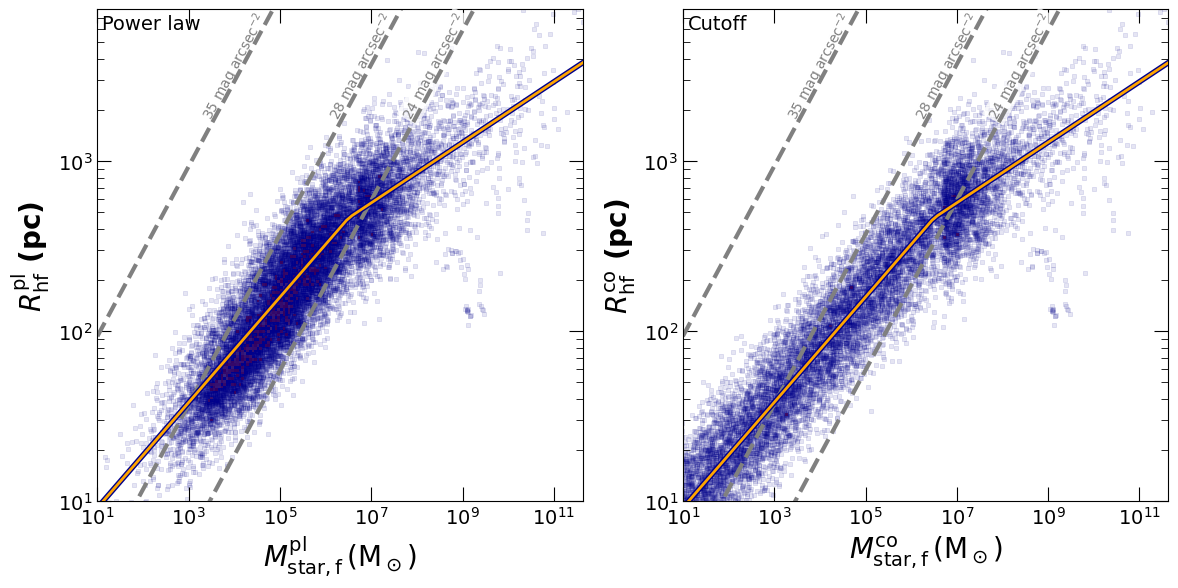

In [20]:
alpha_points = 0.1
size_points = 7.5
def get_line_of_constant_surfb(mstar, S):
    '''
    This is to plot the line of constant surface brightness
    mstar: Stellar mass
    S: Surface brightness

    Returns:
    R: Half light radius in pc
    '''
    logR = -(1/5.)*(4.83+21.57-2.5*np.log10(mstar)+2.5*np.log10(np.pi)-S)
    return 10**logR


def inverse_get_line_of_constant_surfb(R, S):
    '''
    Inverse function of get_line_of_constant_surfb
    R: Half light radius in pc
    S: Surface brightness

    Returns:
    mstar: Stellar mass
    '''
    def equation(mstar):
        return R - get_line_of_constant_surfb(mstar, S)

    mstar_guess = 1e3  # Initial guess for mstar
    mstar_solution = fsolve(equation, mstar_guess)
    return mstar_solution[0]

fig, (ax2, ax) = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6.15))
mspl_log = np.linspace(1, 13, 100)
# plot_lg_virgo(ax)
# plot_lg_virgo(ax2)
a4_mstar_co_all = np.append(a4_t1_mstar_max_co_all, a4_t2_mstar_max_co_all)



    # ax.scatter(csmstar_all[csix], np.array(csrh_all[csix]) * 1e3, marker = 's', fc = 'darkgreen', alpha = alpha_points, s = size_points, label = 'Survived', zorder = 200, edgecolor = 'darkgreen', linewidth = 0.7)
    # ax.scatter(cmmstar_all[cmix], np.array(cmrh_all[cmix]) * 1e3, marker = 's', fc = 'purple', alpha = alpha_points, s = size_points, label = 'Merged', zorder = 200, edgecolor = 'purple', linewidth = 0.7)
    
cmstar = np.append(a4_t1_mstar_max_co_all, a4_t2_mstar_max_co_all) #msun, THis is all the subhalos in the cutoff model
crh = np.append(a4_t1_rh_max_co_all, a4_t2_rh_max_co_all) * 1e3 #kpc, This is rh of all the subhalos in the cutoff model
# cmstar = cmstar[crh > 0]
# crh = crh[crh > 0]

# Check for NaNs, infinite values, or negative values in cmstar and crh arrays
print(len(cmstar))
condition = np.isfinite(cmstar) & (cmstar > 0) & np.isfinite(crh) & (crh > 0)
cmstar = cmstar[condition]
crh = crh[condition]

print('Length of cmstar:', len(cmstar))

pmstar = np.append(a4_t1_mstar_max_pl_all, a4_t2_mstar_max_pl_all)
prh = np.append(a4_t1_rh_max_pl_all, a4_t2_rh_max_pl_all) * 1e3
# pmstar = pmstar[prh > 0]
# prh = prh[prh > 0]

# Check for NaNs, infinite values, or negative values in pmstar and prh arrays
condition = np.isfinite(pmstar) & (pmstar > 0) & np.isfinite(prh) & (prh > 0)
pmstar = pmstar[condition]
prh = prh[condition]


y_space = np.logspace(np.log10(min(crh)), np.log10(max(crh)), 200)
x_space = np.logspace(np.log10(min(cmstar)), np.log10(max(cmstar)), 200)


y_space1 = np.logspace(np.log10(min(prh)), np.log10(max(prh)), 200)
x_space1 = np.logspace(np.log10(min(pmstar)), np.log10(max(pmstar)), 200)

hist1, _, _ = np.histogram2d(cmstar, crh, bins=(x_space, y_space))
hist2, _, _ = np.histogram2d(pmstar, prh, bins=(x_space1, y_space1))

vmin = min(hist1.min(), hist2.min())
vmax = max(hist1.max(), hist2.max())

print(vmin, vmax)

ax.scatter(cmstar, crh, marker = 's', fc = 'darkblue', alpha = alpha_points, s = size_points, zorder = 0, edgecolor = 'darkblue', linewidth = 0.7)
ax.hist2d(cmstar, crh, bins = (x_space1, y_space1), cmin = 9, norm = 'log', zorder = 100, vmin = 9, vmax = vmax, alpha = 0.75)
ax.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'darkblue', zorder = 200, lw = 4)
ax.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'orange', zorder = 200, lw = 2)
top_data = ax.get_ylim()[1]
right_data = ax.get_xlim()[1]
ax.set_xlim(left = 1e1, right = right_data)
ax.set_ylim(bottom = 10, top = top_data)

# ax2.scatter(psmstar_all[psix], np.array(psrh_all[psix]) * 1e3, marker = 's', fc = 'darkgreen', alpha = alpha_points, s = size_points, label = 'Survived', zorder = 200, edgecolor = 'darkgreen', linewidth = 0.7)
# ax2.scatter(pmmstar_all[pmix], np.array(pmrh_all[pmix]) * 1e3, marker = 's', fc = 'purple', alpha = alpha_points, s = size_points, label = 'Merged', zorder = 200, edgecolor = 'purple', linewidth = 0.7)



ax2.scatter(pmstar, prh, marker = 's', fc = 'darkblue', alpha = alpha_points, s = size_points, zorder = 0, edgecolor = 'darkblue', linewidth = 0.7)

ax2.hist2d(pmstar, prh, bins = (x_space1, y_space1), cmin = 9, norm = 'linear', zorder = 100, vmin = 9, vmax = vmax, alpha = 0.75)
ax2.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'darkblue', zorder = 200, lw = 4)
ax2.plot(10**mspl_log, 1e3 * 10**get_lrh(mspl_log), color = 'orange', zorder = 200, lw = 2)
top_data2 = ax2.get_ylim()[1]
right_data2 = ax2.get_xlim()[1]
ax2.set_xlim(left = 1e1, right = right_data2)
ax2.set_ylim(bottom = 10, top = top_data2)


if True: 
    #This section is for lines of constant surface brightness
    angle = 62
    yval = 0.21*top_data
    ax.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 24), ls = '--', color = 'gray', zorder = 50)
    ax.annotate(r'24 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 24), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 24), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))
    ax.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 28), ls = '--', color = 'gray')
    ax.annotate(r'28 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 28), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 28), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor')
    ax.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 35), ls = '--', color = 'gray')
    ax.annotate(r'35 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 35), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 35), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor')

    yval = 0.21*top_data2
    ax2.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 24), ls = '--', color = 'gray', zorder = 50)
    ax2.annotate(r'24 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 24), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 24), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))
    ax2.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 28), ls = '--', color = 'gray')
    ax2.annotate(r'28 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 28), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 28), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor')
    ax2.plot(10**mspl_log, get_line_of_constant_surfb(10**mspl_log, 35), ls = '--', color = 'gray')
    ax2.annotate(r'35 mag arcsec$^{-2}$', xy = (inverse_get_line_of_constant_surfb(yval, 35), yval), xytext = (inverse_get_line_of_constant_surfb(yval, 35), 1.05* yval), 
    rotation=angle, color='gray', fontsize=10, rotation_mode='anchor')


# plot_lg_virgo_some(ax, alpha = 0.2)
# plot_lg_virgo_some(ax2, alpha = 0.2)

# # Example usage:
# R = 100  # Half light radius in pc
# S = 25  # Surface brightness
# mstar_inverse = inverse_get_line_of_constant_surfb(R, S)
# print(mstar_inverse)
ax.set_xlabel(r'$M_{\rm star, f}^{\rm co}\,\rm{(M_\odot)}$', fontsize = label_font)
ax.set_ylabel(r'$R_{\rm{hf}}^{\rm co}$ (pc)', fontsize = label_font)
ax.text(0.01, 0.99, 'Cutoff', ha = 'left', va = 'top', transform=ax.transAxes)
# ax.legend(fontsize = 8, loc = 'lower right')
ax.tick_params(axis='both', which = 'both', left=True, right=True, bottom = True, top = True, direction = 'in')

ax2.set_xlabel(r'$M_{\rm star, f}^{\rm pl}\,\rm{(M_\odot)}$', fontsize = label_font)
ax2.set_ylabel(r'$R_{\rm{hf}}^{\rm pl}$ (pc)', fontsize = label_font)
ax2.text(0.01, 0.99, 'Power law', ha = 'left', va = 'top', transform=ax2.transAxes)
# ax2.legend(fontsize = 8, loc = 'lower right')
ax2.tick_params(axis='both', which = 'both', left=True, right=True, bottom = True, top = True, direction = 'in')

ax.set_xscale('log')
ax.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yscale('log')
# fig.suptitle('FoF'+str(fof_no), fontsize = 14)
plt.tight_layout()
# plt.savefig(this_fof_plotppath + 'rh_vs_mstar_hist.png')
plt.show()
plt.close()

